<a href="https://colab.research.google.com/github/kspohn903/Google_Drive_Repository/blob/main/Lottery_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mega Millions Data Analysis

In [ ]:
import sys
!{sys.executable} -m pip install kaleido
import plotly.io as pio # Ensure plotly.io is imported after kaleido installation

In [ ]:
!pip install -U kaleido

In [ ]:
import os

# Define base path for saving data and graphics
base_output_path = '/content/drive/MyDrive/Lotto_ML_Prediction_Model'

# Define paths for Powerball outputs
pb_data_output_path = os.path.join(base_output_path, 'PowerBall', 'Data')
pb_graphics_output_path = os.path.join(base_output_path, 'PowerBall', 'Graphics')

# Define paths for Mega Millions outputs
mm_data_output_path = os.path.join(base_output_path, 'Mega_Millions', 'Data')
mm_graphics_output_path = os.path.join(base_output_path, 'Mega_Millions', 'Graphics')

# Create directories if they don't exist
os.makedirs(pb_data_output_path, exist_ok=True)
os.makedirs(pb_graphics_output_path, exist_ok=True)
os.makedirs(mm_data_output_path, exist_ok=True)
os.makedirs(mm_graphics_output_path, exist_ok=True)

print(f"Output directories created/ensured at: {base_output_path}")

Output directories created/ensured at: /content/drive/MyDrive/Lotto_ML_Prediction_Model


Powerball data loaded successfully.

Data Preprocessing Complete. First 5 rows of processed data:
   Draw Date  Multiplier  Num1  Num2  Num3  Num4  Num5  Powerball
0 2026-05-23         2.0     4    16    41    48    66         26
1 2026-05-20         3.0    10    28    30    46    57         25
2 2026-05-18         2.0     4    13    34    61    65         12
3 2026-05-16         3.0     8    37    40    44    65         18
4 2026-05-13         2.0    22    31    52    56    67         15

Info about the processed DataFrame:
<class 'pandas.core.frame.DataFrame'>
Index: 1346 entries, 0 to 1345
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Draw Date   1346 non-null   datetime64[ns]
 1   Multiplier  1346 non-null   float64       
 2   Num1        1346 non-null   int64         
 3   Num2        1346 non-null   int64         
 4   Num3        1346 non-null   int64         
 5   Num4        1346 non-null  

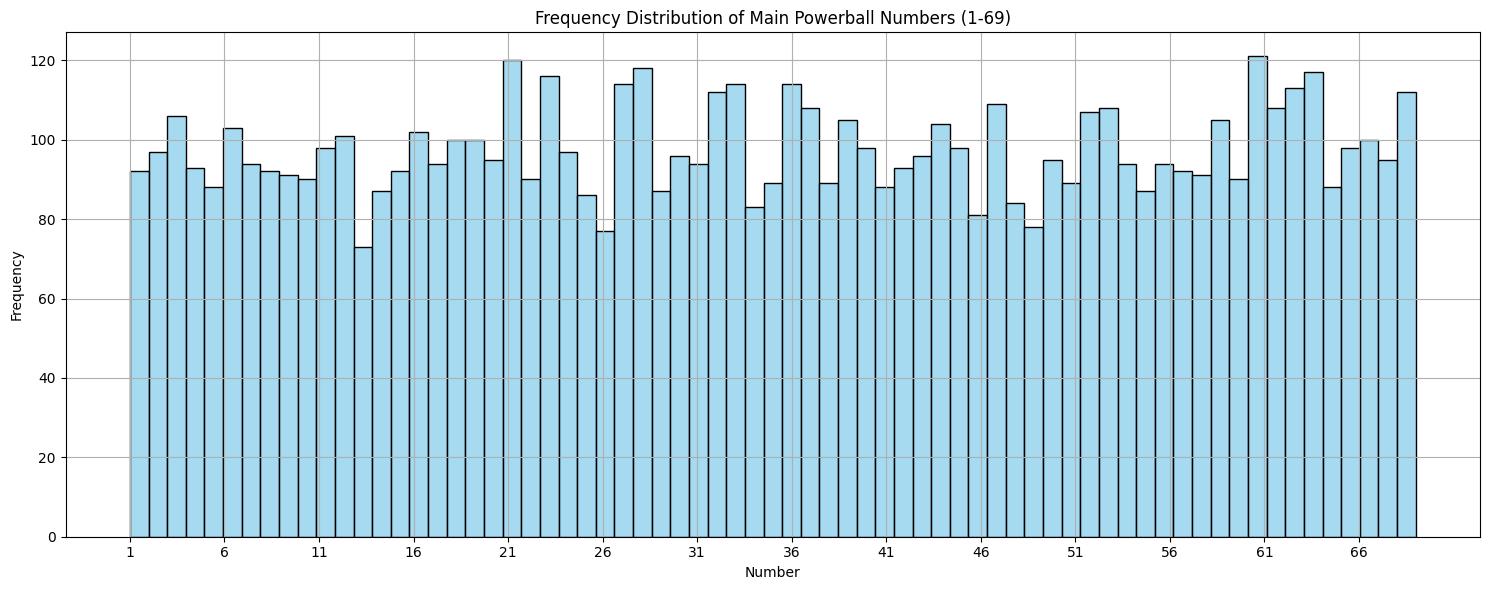

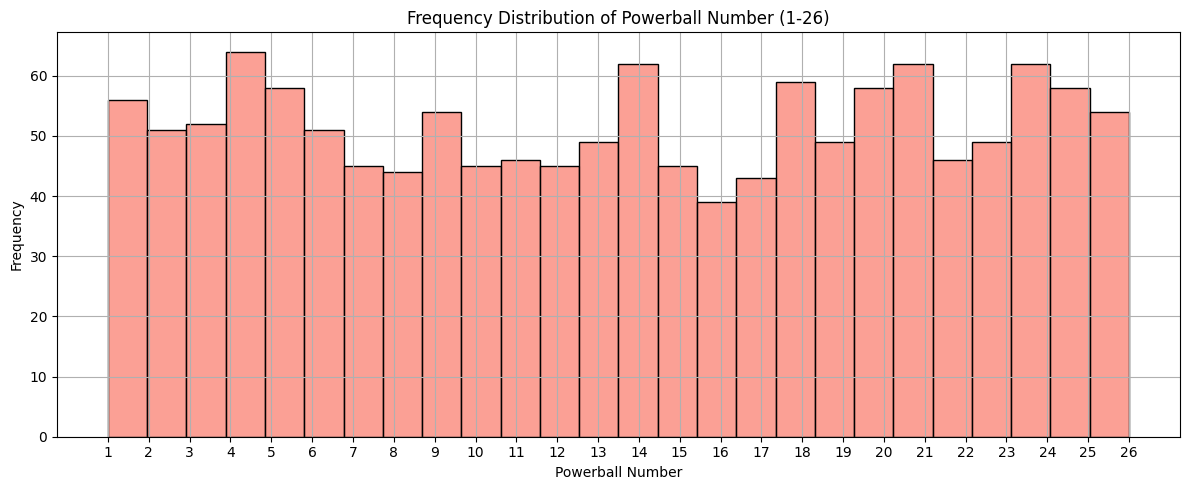

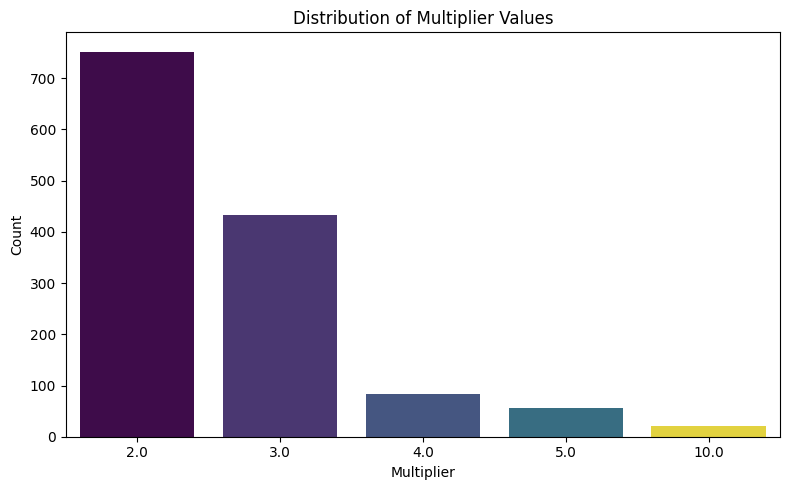

In [ ]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pandas.errors import PerformanceWarning

warnings.filterwarnings('ignore', category=PerformanceWarning)

drive_path = '/content/drive/MyDrive/Lottery_ML_Prediction_Model/'
powerball_file = os.path.join(drive_path, 'Lottery_Powerball_Winning_Numbers__Beginning_2010_20260524.csv')

# Load the Powerball data
try:
    df_powerball = pd.read_csv(powerball_file)
    print("Powerball data loaded successfully.")

    # Convert 'Draw Date' to datetime
    df_powerball['Draw Date'] = pd.to_datetime(df_powerball['Draw Date'])

    # Filter Powerball data for rules change (October 31, 2015)
    df_powerball = df_powerball[df_powerball['Draw Date'] >= '2015-10-31'].copy()

    # Split 'Winning Numbers' into individual number columns
    winning_numbers_split = df_powerball['Winning Numbers'].str.split(' ', expand=True)
    df_powerball['Num1'] = pd.to_numeric(winning_numbers_split[0])
    df_powerball['Num2'] = pd.to_numeric(winning_numbers_split[1])
    df_powerball['Num3'] = pd.to_numeric(winning_numbers_split[2])
    df_powerball['Num4'] = pd.to_numeric(winning_numbers_split[3])
    df_powerball['Num5'] = pd.to_numeric(winning_numbers_split[4])
    df_powerball['Powerball'] = pd.to_numeric(winning_numbers_split[5])

    # Handle missing values in 'Multiplier' by filling with the median
    median_multiplier = df_powerball['Multiplier'].median()
    df_powerball['Multiplier'] = df_powerball['Multiplier'].fillna(median_multiplier)

    # Drop the original 'Winning Numbers' column as it's now parsed
    df_powerball.drop('Winning Numbers', axis=1, inplace=True)

    print("\nData Preprocessing Complete. First 5 rows of processed data:")
    print(df_powerball.head())
    print("\nInfo about the processed DataFrame:")
    df_powerball.info()

    # --- Start EDA --- #

    # Plot frequency of main numbers
    main_numbers = ['Num1', 'Num2', 'Num3', 'Num4', 'Num5']
    all_main_numbers = df_powerball[main_numbers].melt(var_name='Number Type', value_name='Number')

    plt.figure(figsize=(15, 6))
    sns.histplot(all_main_numbers['Number'], bins=69, kde=False, color='skyblue')
    plt.title('Frequency Distribution of Main Powerball Numbers (1-69)')
    plt.xlabel('Number')
    plt.ylabel('Frequency')
    plt.xticks(range(1, 70, 5)) # Assuming numbers are 1-69
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot frequency of Powerball numbers
    plt.figure(figsize=(12, 5))
    sns.histplot(df_powerball['Powerball'], bins=26, kde=False, color='salmon')
    plt.title('Frequency Distribution of Powerball Number (1-26)')
    plt.xlabel('Powerball Number')
    plt.ylabel('Frequency')
    plt.xticks(range(1, 27))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot distribution of Multiplier
    plt.figure(figsize=(8, 5))
    sns.countplot(x='Multiplier', data=df_powerball, palette='viridis', hue='Multiplier', legend=False)
    plt.title('Distribution of Multiplier Values')
    plt.xlabel('Multiplier')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"Error: Powerball file not found at {powerball_file}")
except Exception as e:
    print(f"An error occurred during data loading or preprocessing or EDA: {e}")

In [ ]:
# Save the processed Powerball DataFrame
df_powerball.to_csv(os.path.join(pb_data_output_path, 'df_powerball_processed.csv'), index=False)
print(f"'df_powerball_processed.csv' saved to {pb_data_output_path}")

# Save Powerball Main Numbers Frequency Plot
plt.figure(figsize=(15, 6))
sns.histplot(all_main_numbers['Number'], bins=69, kde=False, color='skyblue')
plt.title('Frequency Distribution of Main Powerball Numbers (1-69)')
plt.xlabel('Number')
plt.ylabel('Frequency')
plt.xticks(range(1, 70, 5))
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(pb_graphics_output_path, 'powerball_main_numbers_frequency.png'))
plt.close()
print(f"'powerball_main_numbers_frequency.png' saved to {pb_graphics_output_path}")

# Save Powerball Number Frequency Plot
plt.figure(figsize=(12, 5))
sns.histplot(df_powerball['Powerball'], bins=26, kde=False, color='salmon')
plt.title('Frequency Distribution of Powerball Number (1-26)')
plt.xlabel('Powerball Number')
plt.ylabel('Frequency')
plt.xticks(range(1, 27))
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(pb_graphics_output_path, 'powerball_number_frequency.png'))
plt.close()
print(f"'powerball_number_frequency.png' saved to {pb_graphics_output_path}")

# Save Multiplier Distribution Plot
plt.figure(figsize=(8, 5))
sns.countplot(x='Multiplier', data=df_powerball, palette='viridis', hue='Multiplier', legend=False)
plt.title('Distribution of Multiplier Values')
plt.xlabel('Multiplier')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(pb_graphics_output_path, 'powerball_multiplier_distribution.png'))
plt.close()
print(f"'powerball_multiplier_distribution.png' saved to {pb_graphics_output_path}")

'df_powerball_processed.csv' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/PowerBall/Data
'powerball_main_numbers_frequency.png' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/PowerBall/Graphics
'powerball_number_frequency.png' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/PowerBall/Graphics
'powerball_multiplier_distribution.png' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/PowerBall/Graphics


### Time-Series Analysis: Recent Frequency of Numbers

Let's analyze if certain numbers have appeared more frequently recently by plotting their rolling frequency over time. We'll look at both the main numbers and the Powerball number.

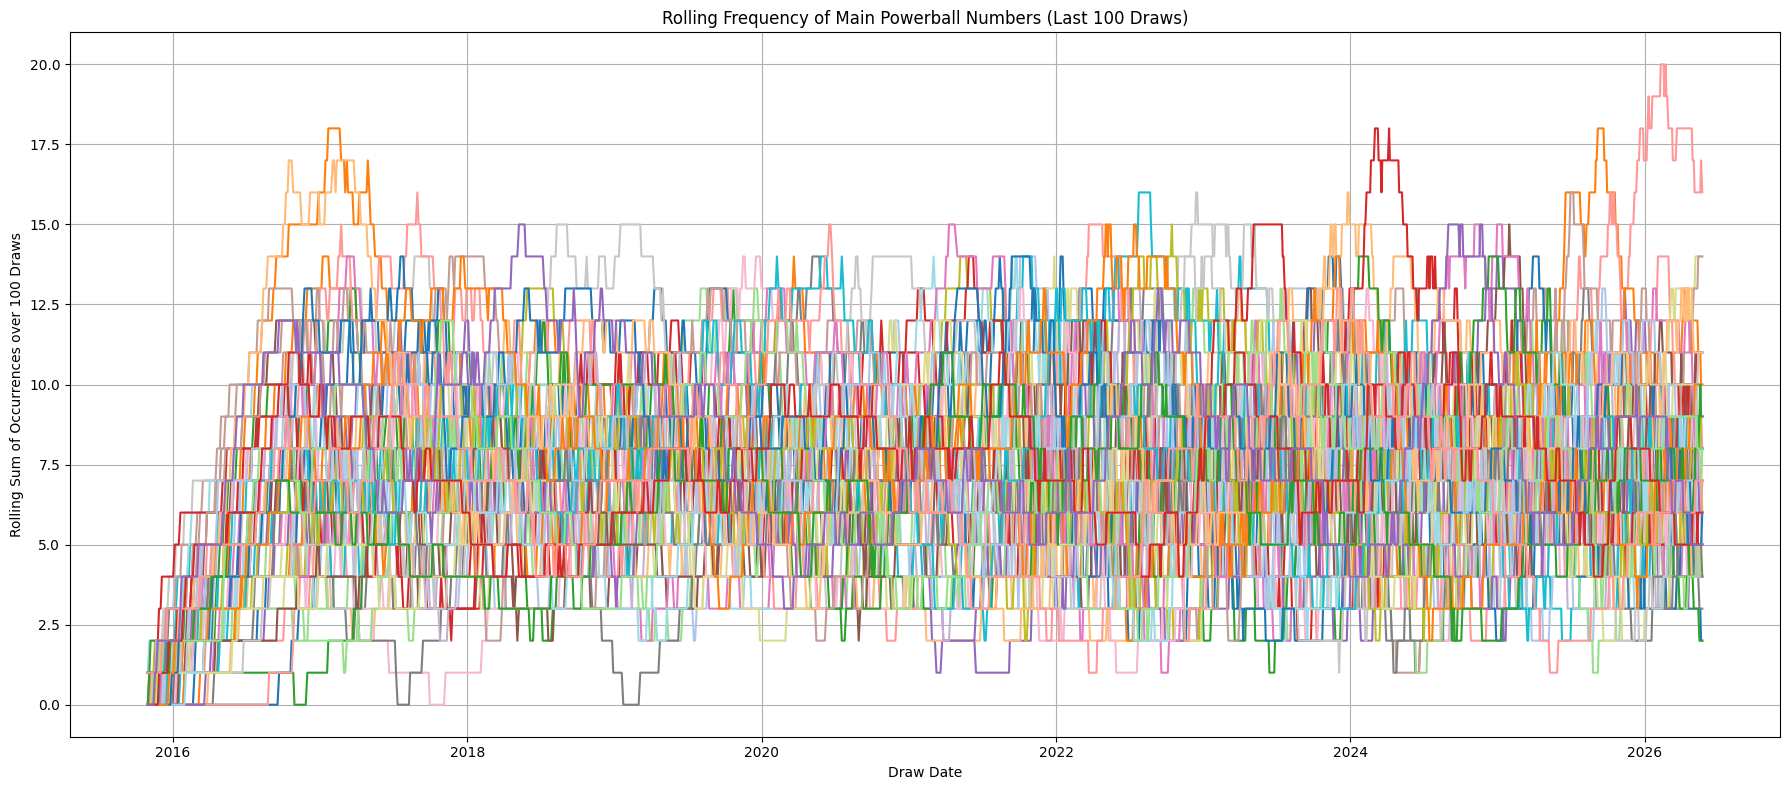

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the DataFrame by Draw Date to ensure correct time-series analysis
df_powerball_sorted = df_powerball.sort_values(by='Draw Date').copy()

# Prepare data for main numbers frequency over time
main_numbers_cols = ['Num1', 'Num2', 'Num3', 'Num4', 'Num5']
all_main_numbers_series = df_powerball_sorted[main_numbers_cols].stack().reset_index(name='Number')
all_main_numbers_series['Draw Date'] = df_powerball_sorted['Draw Date'].iloc[all_main_numbers_series['level_0']].values

# Calculate a rolling count for each main number (e.g., over the last 100 draws)
# This is a bit complex as we need frequency per number, not overall
# A simpler approach for visualization is to see the trend of *any* number being drawn at a given time
# For specific number trends, we can count occurrences per month/year or use a window.

# Let's track the frequency of individual numbers over a rolling window (e.g., 50 draws)
# This is more illustrative for identifying recent 'hot' or 'cold' numbers

rolling_window_size = 100 # Number of draws for the rolling window

# Create a list to store frequency data for each main number
main_num_freq_data = []
for num in range(1, 70): # Numbers 1-69 for main Powerball numbers
    # Check if 'num' appeared in any of the 5 main number columns for each draw
    df_powerball_sorted[f'num_{num}_present'] = df_powerball_sorted[main_numbers_cols].apply(lambda row: num in row.values, axis=1).astype(int)
    df_powerball_sorted[f'num_{num}_rolling_freq'] = df_powerball_sorted[f'num_{num}_present'].rolling(window=rolling_window_size, min_periods=1).sum()
    main_num_freq_data.append(df_powerball_sorted[['Draw Date', f'num_{num}_rolling_freq']].rename(columns={f'num_{num}_rolling_freq': 'Rolling Frequency'}).assign(Number=num))

main_num_rolling_df = pd.concat(main_num_freq_data)

plt.figure(figsize=(18, 8))
sns.lineplot(data=main_num_rolling_df, x='Draw Date', y='Rolling Frequency', hue='Number', palette='tab20', legend=False)
plt.title(f'Rolling Frequency of Main Powerball Numbers (Last {rolling_window_size} Draws)')
plt.xlabel('Draw Date')
plt.ylabel(f'Rolling Sum of Occurrences over {rolling_window_size} Draws')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Save the main numbers rolling frequency DataFrame
main_num_rolling_df.to_csv(os.path.join(pb_data_output_path, 'powerball_main_numbers_rolling_frequency.csv'), index=False)
print(f"'powerball_main_numbers_rolling_frequency.csv' saved to {pb_data_output_path}")

# Save the rolling frequency plot for main Powerball numbers
plt.figure(figsize=(18, 8))
sns.lineplot(data=main_num_rolling_df, x='Draw Date', y='Rolling Frequency', hue='Number', palette='tab20', legend=False)
plt.title(f'Rolling Frequency of Main Powerball Numbers (Last {rolling_window_size} Draws)')
plt.xlabel('Draw Date')
plt.ylabel(f'Rolling Sum of Occurrences over {rolling_window_size} Draws')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(pb_graphics_output_path, 'powerball_main_numbers_rolling_frequency.png'))
plt.close()
print(f"'powerball_main_numbers_rolling_frequency.png' saved to {pb_graphics_output_path}")

'powerball_main_numbers_rolling_frequency.csv' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/PowerBall/Data
'powerball_main_numbers_rolling_frequency.png' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/PowerBall/Graphics


The above plot shows the rolling frequency of each main number. It can be a bit crowded with all 69 numbers. Let's do the same for the Powerball number, which has a smaller range.

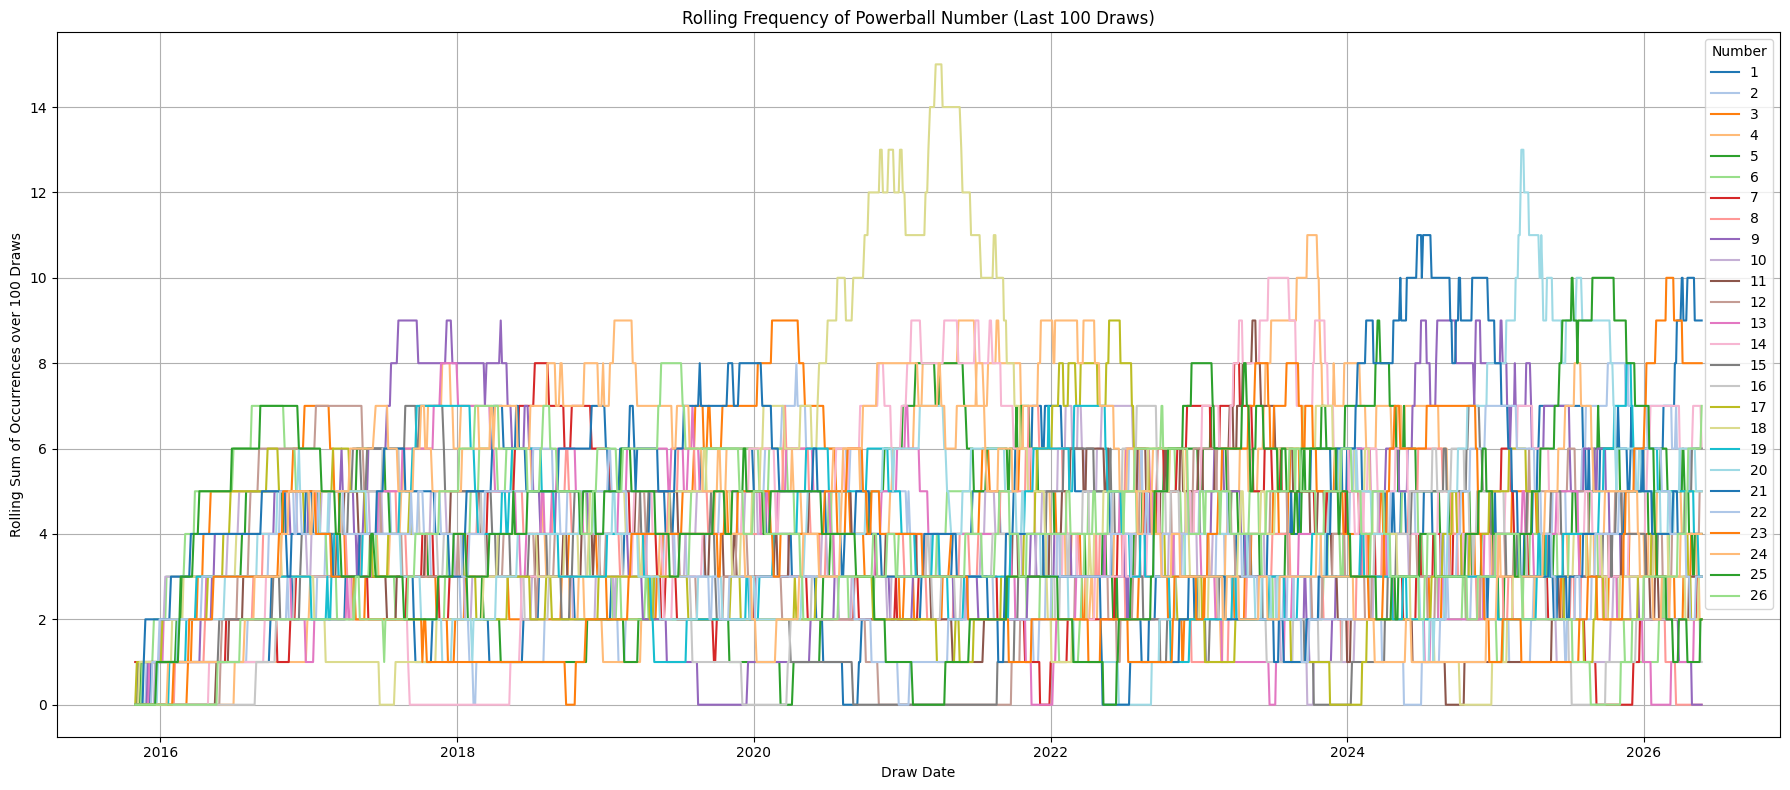

In [ ]:
rolling_window_size = 100 # Number of draws for the rolling window

powerball_num_freq_data = []
for num in range(1, 27): # Powerball numbers 1-26
    df_powerball_sorted[f'pb_{num}_present'] = (df_powerball_sorted['Powerball'] == num).astype(int)
    df_powerball_sorted[f'pb_{num}_rolling_freq'] = df_powerball_sorted[f'pb_{num}_present'].rolling(window=rolling_window_size, min_periods=1).sum()
    powerball_num_freq_data.append(df_powerball_sorted[['Draw Date', f'pb_{num}_rolling_freq']].rename(columns={f'pb_{num}_rolling_freq': 'Rolling Frequency'}).assign(Number=num))

powerball_num_rolling_df = pd.concat(powerball_num_freq_data)

plt.figure(figsize=(18, 8))
sns.lineplot(data=powerball_num_rolling_df, x='Draw Date', y='Rolling Frequency', hue='Number', palette='tab20', legend='full')
plt.title(f'Rolling Frequency of Powerball Number (Last {rolling_window_size} Draws)')
plt.xlabel('Draw Date')
plt.ylabel(f'Rolling Sum of Occurrences over {rolling_window_size} Draws')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Save the powerball number rolling frequency DataFrame
powerball_num_rolling_df.to_csv(os.path.join(pb_data_output_path, 'powerball_number_rolling_frequency.csv'), index=False)
print(f"'powerball_number_rolling_frequency.csv' saved to {pb_data_output_path}")

# Save the rolling frequency plot for Powerball number
plt.figure(figsize=(18, 8))
sns.lineplot(data=powerball_num_rolling_df, x='Draw Date', y='Rolling Frequency', hue='Number', palette='tab20', legend='full')
plt.title(f'Rolling Frequency of Powerball Number (Last {rolling_window_size} Draws)')
plt.xlabel('Draw Date')
plt.ylabel(f'Rolling Sum of Occurrences over {rolling_window_size} Draws')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(pb_graphics_output_path, 'powerball_number_rolling_frequency.png'))
plt.close()
print(f"'powerball_number_rolling_frequency.png' saved to {pb_graphics_output_path}")

'powerball_number_rolling_frequency.csv' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/PowerBall/Data
'powerball_number_rolling_frequency.png' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/PowerBall/Graphics


### Feature Engineering: Creating Lagged Features

To predict future numbers, we'll use past winning numbers as features. We'll create lagged versions of the `Num1` through `Num5` and `Powerball` columns. This means, for each draw, the features will be the winning numbers from the previous draw. We'll then drop any rows with NaN values resulting from the lagging operation.

In [ ]:
# Sort the DataFrame by Draw Date (already sorted by previous EDA steps, but good practice to ensure)
df_model = df_powerball.sort_values(by='Draw Date').copy()

# Define the number columns we want to lag
number_cols = ['Num1', 'Num2', 'Num3', 'Num4', 'Num5', 'Powerball']

# Create lagged features for each number column
for col in number_cols:
    df_model[f'lag_1_{col}'] = df_model[col].shift(1)

# Drop rows with NaN values (the first row after lagging will have NaNs)
df_model.dropna(inplace=True)

# Display the first few rows with lagged features
print("DataFrame with lagged features (first 5 rows):")
display(df_model.head())

print("\nInfo about the DataFrame with lagged features:")
df_model.info()

DataFrame with lagged features (first 5 rows):


,Draw Date,Multiplier,Num1,Num2,Num3,Num4,Num5,Powerball,lag_1_Num1,lag_1_Num2,lag_1_Num3,lag_1_Num4,lag_1_Num5,lag_1_Powerball
1344,2015-11-04,4.0,2,12,17,20,65,17,9.0,20.0,25.0,47.0,68.0,7.0
1343,2015-11-07,2.0,7,16,25,50,53,15,2.0,12.0,17.0,20.0,65.0,17.0
1342,2015-11-11,3.0,4,26,32,55,64,18,7.0,16.0,25.0,50.0,53.0,15.0
1341,2015-11-14,3.0,14,22,37,45,66,5,4.0,26.0,32.0,55.0,64.0,18.0
1340,2015-11-18,2.0,17,40,41,46,69,6,14.0,22.0,37.0,45.0,66.0,5.0



Info about the DataFrame with lagged features:
<class 'pandas.core.frame.DataFrame'>
Index: 1345 entries, 1344 to 0
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Draw Date        1345 non-null   datetime64[ns]
 1   Multiplier       1345 non-null   float64       
 2   Num1             1345 non-null   int64         
 3   Num2             1345 non-null   int64         
 4   Num3             1345 non-null   int64         
 5   Num4             1345 non-null   int64         
 6   Num5             1345 non-null   int64         
 7   Powerball        1345 non-null   int64         
 8   lag_1_Num1       1345 non-null   float64       
 9   lag_1_Num2       1345 non-null   float64       
 10  lag_1_Num3       1345 non-null   float64       
 11  lag_1_Num4       1345 non-null   float64       
 12  lag_1_Num5       1345 non-null   float64       
 13  lag_1_Powerball  1345 non-null   float64       
dt

In [ ]:
# Save the Powerball model DataFrame with lagged features
df_model.to_csv(os.path.join(pb_data_output_path, 'df_powerball_model_lagged_features.csv'), index=False)
print(f"'df_powerball_model_lagged_features.csv' saved to {pb_data_output_path}")

'df_powerball_model_lagged_features.csv' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/PowerBall/Data


### Defining Features (X) and Targets (y) and Splitting Data

Now we'll define our feature matrix `X` (the lagged numbers) and our target variables `y` (the current winning numbers). Since we're dealing with time-series data, we'll perform a time-based split, using an older portion of the data for training and a newer portion for testing.

In [ ]:
from sklearn.model_selection import train_test_split

# Features (X) will be the lagged numbers
feature_cols = [f'lag_1_{col}' for col in number_cols]
X = df_model[feature_cols]

# Target (y) will be the current winning numbers
target_cols = number_cols # The original (current) number columns
y = df_model[target_cols]

# For time-series data, we split based on time. Let's use 80% for training and 20% for testing.
split_point = int(len(df_model) * 0.8)

X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (1076, 6)
Shape of X_test: (269, 6)
Shape of y_train: (1076, 6)
Shape of y_test: (269, 6)


### Model Training: RandomForestRegressor

We'll train a `RandomForestRegressor` model to predict the next set of 6 Powerball numbers using the lagged features. We'll train the model on `X_train` and `y_train`.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the RandomForestRegressor model
# n_estimators: number of trees in the forest
# random_state: for reproducibility
# We will keep other parameters as default for initial training
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available processors

# Train the model
print("Training the RandomForestRegressor model...")
model.fit(X_train, y_train)
print("Model training complete.")

# Make predictions on the test set
y_pred = model.predict(X_test)

print("\nFirst 5 predictions (rounded to nearest integer as numbers are integers):")
print(np.round(y_pred[:5]))

print("\nFirst 5 actual values from the test set:")
print(y_test.head().values)


Training the RandomForestRegressor model...
Model training complete.

First 5 predictions (rounded to nearest integer as numbers are integers):
[[11. 21. 32. 45. 55. 14.]
 [11. 24. 41. 51. 61. 13.]
 [11. 21. 37. 48. 58. 15.]
 [15. 26. 35. 44. 59. 13.]
 [15. 26. 35. 44. 56. 13.]]

First 5 actual values from the test set:
[[ 7 10 21 33 59 20]
 [14 34 37 55 63 20]
 [ 1 16 21 47 60  5]
 [10 12 55 65 67  3]
 [29 34 38 48 56 16]]


### Model Evaluation: Lottery-Specific Metrics

Let's evaluate the model based on metrics that are more relevant to lottery predictions than standard regression metrics. We'll look at the number of correctly predicted main balls and the Powerball number.

In [ ]:
import numpy as np

# Round predictions to the nearest integer as lottery numbers are integers
y_pred_rounded = np.round(y_pred).astype(int)
y_test_np = y_test.values

# Ensure predicted numbers are within valid ranges (1-69 for main, 1-26 for Powerball)
# Main numbers (Num1-Num5)
y_pred_rounded[:, :5] = np.clip(y_pred_rounded[:, :5], 1, 69)
# Powerball number
y_pred_rounded[:, 5] = np.clip(y_pred_rounded[:, 5], 1, 26)

# --- Evaluation Metrics ---

# 1. Number of Exact Matches (Main Balls)
main_matches_per_draw = []
powerball_matches = []

for i in range(len(y_test_np)):
    actual_main_balls = set(y_test_np[i, :5])
    predicted_main_balls = set(y_pred_rounded[i, :5])

    # Count common elements (intersection) for main balls
    main_matches = len(actual_main_balls.intersection(predicted_main_balls))
    main_matches_per_draw.append(main_matches)

    # Check for Powerball match
    if y_test_np[i, 5] == y_pred_rounded[i, 5]:
        powerball_matches.append(1)
    else:
        powerball_matches.append(0)

print(f"Average number of main balls matched per draw: {np.mean(main_matches_per_draw):.2f} out of 5")
print(f"Powerball match accuracy: {np.mean(powerball_matches):.2%}")

# 2. Overall Number Accuracy (for main balls individually, ignoring position)
# This checks if an actual winning number was predicted anywhere among the 5 main predicted numbers
# (Note: This is a less strict metric than position-specific accuracy)

correct_main_number_predictions = 0
total_main_numbers = y_test_np[:, :5].size

for i in range(len(y_test_np)):
    actual_main = set(y_test_np[i, :5])
    predicted_main = set(y_pred_rounded[i, :5])
    correct_main_number_predictions += len(actual_main.intersection(predicted_main))

print(f"Overall individual main number prediction accuracy (ignoring position): {correct_main_number_predictions / total_main_numbers:.2%}")

# Optional: Check if a full jackpot was ever predicted (highly unlikely)
jackpot_hits = 0
for i in range(len(y_test_np)):
    if (set(y_test_np[i, :5]) == set(y_pred_rounded[i, :5])) and (y_test_np[i, 5] == y_pred_rounded[i, 5]):
        jackpot_hits += 1

print(f"Number of jackpot hits (all 5 main + Powerball correct): {jackpot_hits}")


Average number of main balls matched per draw: 0.36 out of 5
Powerball match accuracy: 4.46%
Overall individual main number prediction accuracy (ignoring position): 7.14%
Number of jackpot hits (all 5 main + Powerball correct): 0


### Mega Millions Data Preprocessing and Initial EDA

Now, let's apply a similar preprocessing and initial exploratory data analysis pipeline to the Mega Millions dataset.

Mega Millions data loaded successfully.

Mega Millions Data Preprocessing Complete. First 5 rows of processed data:


,Draw Date,Mega Ball,Multiplier,Num1,Num2,Num3,Num4,Num5
0,2024-10-11,20,3.0,3,10,29,52,57
1,2024-10-08,9,3.0,3,19,20,22,66
2,2024-10-04,3,2.0,21,39,42,43,45
3,2024-10-01,25,2.0,27,35,47,50,66
4,2024-09-27,23,2.0,29,46,53,69,70



Info about the processed Mega Millions DataFrame:
<class 'pandas.core.frame.DataFrame'>
Index: 726 entries, 0 to 725
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Draw Date   726 non-null    datetime64[ns]
 1   Mega Ball   726 non-null    int64         
 2   Multiplier  726 non-null    float64       
 3   Num1        726 non-null    int64         
 4   Num2        726 non-null    int64         
 5   Num3        726 non-null    int64         
 6   Num4        726 non-null    int64         
 7   Num5        726 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(6)
memory usage: 51.0 KB

Starting EDA for Mega Millions...


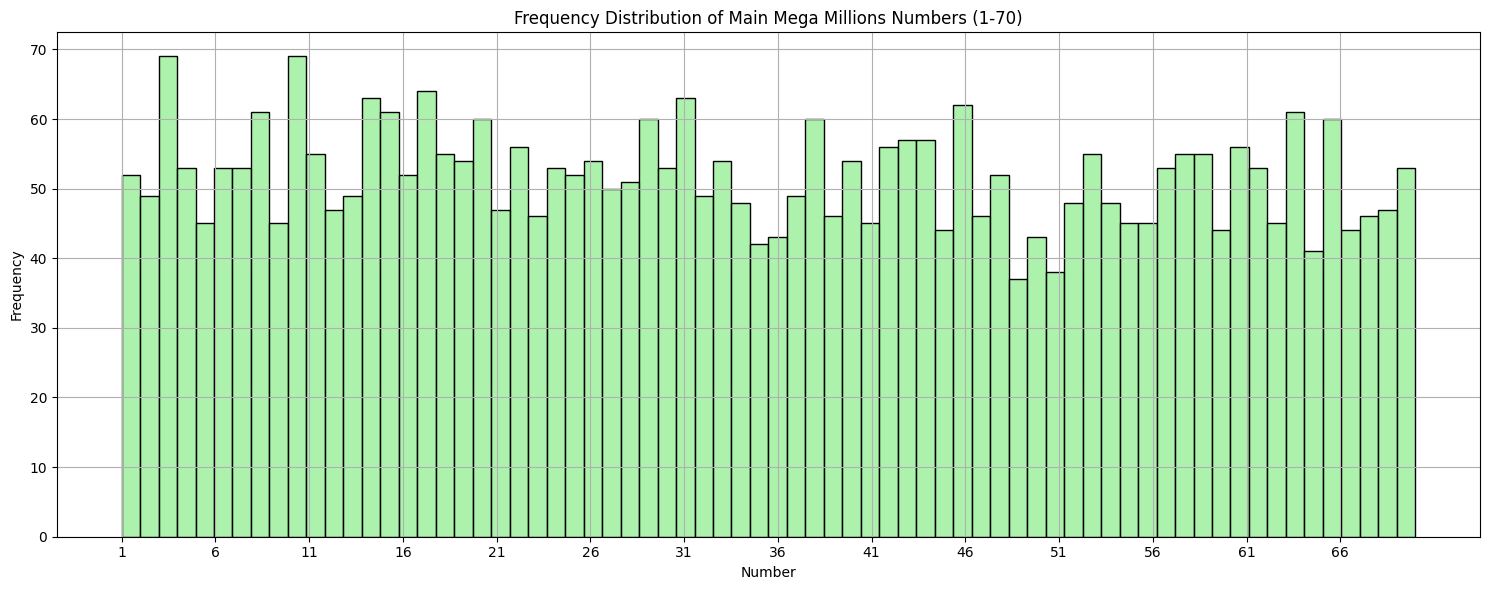

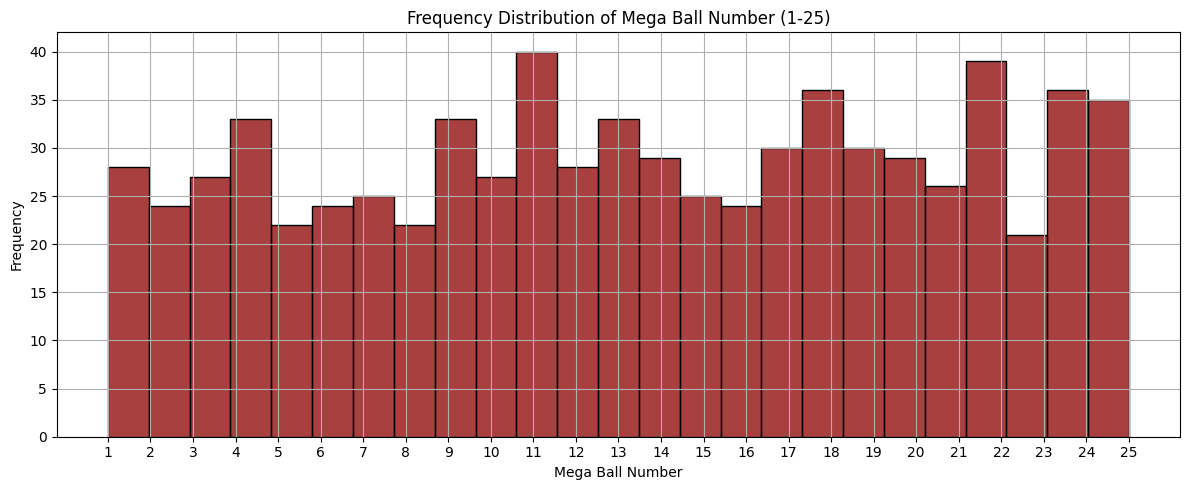

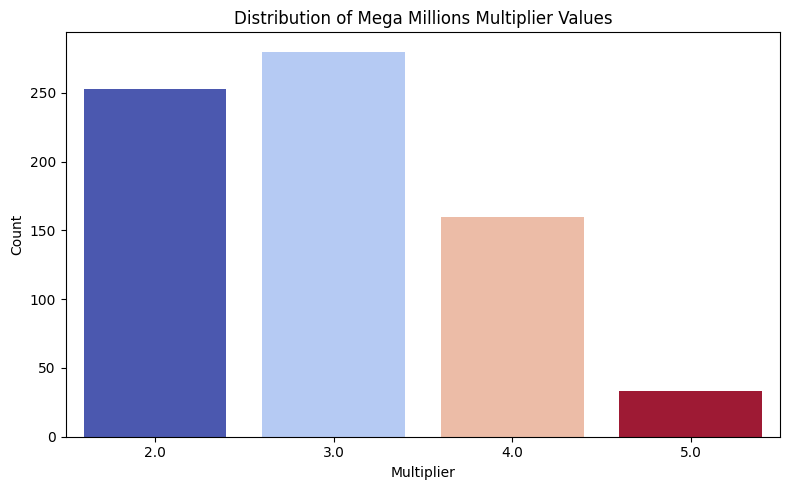

In [ ]:
megamillions_file = os.path.join('/content/drive/MyDrive/Lotto_Analysis/', 'Lottery_Mega_Millions_Winning_Numbers__Beginning_2002_20241013.csv')

try:
    df_megamillions = pd.read_csv(megamillions_file)
    print("Mega Millions data loaded successfully.")

    # Convert 'Draw Date' to datetime
    df_megamillions['Draw Date'] = pd.to_datetime(df_megamillions['Draw Date'])

    # Filter Mega Millions data for rules change (October 28, 2017)
    df_megamillions = df_megamillions[df_megamillions['Draw Date'] >= '2017-10-28'].copy()

    # Split 'Winning Numbers' into individual number columns
    winning_numbers_split_mm = df_megamillions['Winning Numbers'].str.split(' ', expand=True)
    df_megamillions['Num1'] = pd.to_numeric(winning_numbers_split_mm[0])
    df_megamillions['Num2'] = pd.to_numeric(winning_numbers_split_mm[1])
    df_megamillions['Num3'] = pd.to_numeric(winning_numbers_split_mm[2])
    df_megamillions['Num4'] = pd.to_numeric(winning_numbers_split_mm[3])
    df_megamillions['Num5'] = pd.to_numeric(winning_numbers_split_mm[4])

    # Handle missing values in 'Multiplier' by filling with the median (if it exists)
    if 'Multiplier' in df_megamillions.columns:
        median_multiplier_mm = df_megamillions['Multiplier'].median()
        df_megamillions['Multiplier'] = df_megamillions['Multiplier'].fillna(median_multiplier_mm)
    else:
        print("Multiplier column not found in Mega Millions dataset.")

    # Drop the original 'Winning Numbers' column as it's now parsed
    df_megamillions.drop('Winning Numbers', axis=1, inplace=True)

    print("\nMega Millions Data Preprocessing Complete. First 5 rows of processed data:")
    display(df_megamillions.head())
    print("\nInfo about the processed Mega Millions DataFrame:")
    df_megamillions.info()

    # --- Start EDA for Mega Millions --- #

    print("\nStarting EDA for Mega Millions...")

    # Plot frequency of main Mega Millions numbers (1-70)
    main_mm_numbers = ['Num1', 'Num2', 'Num3', 'Num4', 'Num5']
    all_main_mm_numbers = df_megamillions[main_mm_numbers].melt(var_name='Number Type', value_name='Number')

    plt.figure(figsize=(15, 6))
    sns.histplot(all_main_mm_numbers['Number'], bins=70, kde=False, color='lightgreen')
    plt.title('Frequency Distribution of Main Mega Millions Numbers (1-70)')
    plt.xlabel('Number')
    plt.ylabel('Frequency')
    plt.xticks(range(1, 71, 5)) # Assuming numbers are 1-70
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot frequency of Mega Ball numbers (1-25)
    plt.figure(figsize=(12, 5))
    sns.histplot(df_megamillions['Mega Ball'], bins=25, kde=False, color='darkred')
    plt.title('Frequency Distribution of Mega Ball Number (1-25)')
    plt.xlabel('Mega Ball Number')
    plt.ylabel('Frequency')
    plt.xticks(range(1, 26))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot distribution of Multiplier (if present)
    if 'Multiplier' in df_megamillions.columns:
        plt.figure(figsize=(8, 5))
        sns.countplot(x='Multiplier', data=df_megamillions, palette='coolwarm', hue='Multiplier', legend=False)
        plt.title('Distribution of Mega Millions Multiplier Values')
        plt.xlabel('Multiplier')
        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()

except FileNotFoundError:
    print(f"Error: Mega Millions file not found at {megamillions_file}. Please ensure the file exists at this path or provide the correct path/filename.")
except Exception as e:
    print(f"An error occurred during Mega Millions data loading or preprocessing or EDA: {e}")

In [ ]:
# Re-load df_megamillions to ensure 'Winning Numbers' column is present for parsing
# This is necessary because the upstream cell dropped 'Winning Numbers' without parsing it.
megamillions_file = os.path.join('/content/drive/MyDrive/Lotto_Analysis/', 'Lottery_Mega_Millions_Winning_Numbers__Beginning_2002_20241013.csv')
df_megamillions = pd.read_csv(megamillions_file)

# Convert 'Draw Date' to datetime
df_megamillions['Draw Date'] = pd.to_datetime(df_megamillions['Draw Date'])

# Split 'Winning Numbers' into individual number columns for Mega Millions
# Assuming 'Winning Numbers' contains the 5 main numbers separated by spaces
winning_numbers_split_mm = df_megamillions['Winning Numbers'].str.split(' ', expand=True)
df_megamillions['Num1'] = pd.to_numeric(winning_numbers_split_mm[0])
df_megamillions['Num2'] = pd.to_numeric(winning_numbers_split_mm[1])
df_megamillions['Num3'] = pd.to_numeric(winning_numbers_split_mm[2])
df_megamillions['Num4'] = pd.to_numeric(winning_numbers_split_mm[3])
df_megamillions['Num5'] = pd.to_numeric(winning_numbers_split_mm[4])

# Handle missing values in 'Multiplier' by filling with the median (if it exists)
if 'Multiplier' in df_megamillions.columns:
    median_multiplier_mm = df_megamillions['Multiplier'].median()
    df_megamillions['Multiplier'] = df_megamillions['Multiplier'].fillna(median_multiplier_mm)
# If 'Multiplier' column is not initially present, the subsequent plotting conditional handles it.

# Drop the original 'Winning Numbers' column as it's now parsed
df_megamillions.drop('Winning Numbers', axis=1, inplace=True)

# Now proceed with saving and plotting as originally intended in cell c8403077
df_megamillions.to_csv(os.path.join(mm_data_output_path, 'df_megamillions_processed.csv'), index=False)
print(f"'df_megamillions_processed.csv' saved to {mm_data_output_path}")

# Define main_mm_numbers and all_main_mm_numbers for plotting in this cell
main_mm_numbers = ['Num1', 'Num2', 'Num3', 'Num4', 'Num5']
all_main_mm_numbers = df_megamillions[main_mm_numbers].melt(var_name='Number Type', value_name='Number')

# Save Mega Millions Main Numbers Frequency Plot
plt.figure(figsize=(15, 6))
sns.histplot(all_main_mm_numbers['Number'], bins=70, kde=False, color='lightgreen')
plt.title('Frequency Distribution of Main Mega Millions Numbers (1-70)')
plt.xlabel('Number')
plt.ylabel('Frequency')
plt.xticks(range(1, 71, 5))
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(mm_graphics_output_path, 'megamillions_main_numbers_frequency.png'))
plt.close()
print(f"'megamillions_main_numbers_frequency.png' saved to {mm_graphics_output_path}")

# Save Mega Ball Number Frequency Plot
plt.figure(figsize=(12, 5))
sns.histplot(df_megamillions['Mega Ball'], bins=25, kde=False, color='darkred')
plt.title('Frequency Distribution of Mega Ball Number (1-25)')
plt.xlabel('Mega Ball Number')
plt.ylabel('Frequency')
plt.xticks(range(1, 26))
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(mm_graphics_output_path, 'megamillions_megaball_number_frequency.png'))
plt.close()
print(f"'megamillions_megaball_number_frequency.png' saved to {mm_graphics_output_path}")

# Save Multiplier Distribution Plot (if present)
if 'Multiplier' in df_megamillions.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(x='Multiplier', data=df_megamillions, palette='coolwarm', hue='Multiplier', legend=False)
    plt.title('Distribution of Mega Millions Multiplier Values')
    plt.xlabel('Multiplier')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig(os.path.join(mm_graphics_output_path, 'megamillions_multiplier_distribution.png'))
    plt.close()
    print(f"'megamillions_multiplier_distribution.png' saved to {mm_graphics_output_path}")

'df_megamillions_processed.csv' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/Mega_Millions/Data
'megamillions_main_numbers_frequency.png' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/Mega_Millions/Graphics
'megamillions_megaball_number_frequency.png' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/Mega_Millions/Graphics
'megamillions_multiplier_distribution.png' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/Mega_Millions/Graphics


In [ ]:
# Re-execute Mega Millions data and graphics saving
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_megamillions and mm_data_output_path, mm_graphics_output_path are defined from previous cells

# Save the processed Mega Millions DataFrame (if not already saved successfully)
df_megamillions.to_csv(os.path.join(mm_data_output_path, 'df_megamillions_processed.csv'), index=False)
print(f"'df_megamillions_processed.csv' saved to {mm_data_output_path}")

# Re-define main_mm_numbers and all_main_mm_numbers for plotting
main_mm_numbers = ['Num1', 'Num2', 'Num3', 'Num4', 'Num5']
all_main_mm_numbers = df_megamillions[main_mm_numbers].melt(var_name='Number Type', value_name='Number')

# Save Mega Millions Main Numbers Frequency Plot
plt.figure(figsize=(15, 6))
sns.histplot(all_main_mm_numbers['Number'], bins=70, kde=False, color='lightgreen')
plt.title('Frequency Distribution of Main Mega Millions Numbers (1-70)')
plt.xlabel('Number')
plt.ylabel('Frequency')
plt.xticks(range(1, 71, 5))
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(mm_graphics_output_path, 'megamillions_main_numbers_frequency.png'))
plt.close()
print(f"'megamillions_main_numbers_frequency.png' saved to {mm_graphics_output_path}")

# Save Mega Ball Number Frequency Plot
plt.figure(figsize=(12, 5))
sns.histplot(df_megamillions['Mega Ball'], bins=25, kde=False, color='darkred')
plt.title('Frequency Distribution of Mega Ball Number (1-25)')
plt.xlabel('Mega Ball Number')
plt.ylabel('Frequency')
plt.xticks(range(1, 26))
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(mm_graphics_output_path, 'megamillions_megaball_number_frequency.png'))
plt.close()
print(f"'megamillions_megaball_number_frequency.png' saved to {mm_graphics_output_path}")

# Save Multiplier Distribution Plot (if present)
if 'Multiplier' in df_megamillions.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(x='Multiplier', data=df_megamillions, palette='coolwarm', hue='Multiplier', legend=False)
    plt.title('Distribution of Mega Millions Multiplier Values')
    plt.xlabel('Multiplier')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig(os.path.join(mm_graphics_output_path, 'megamillions_multiplier_distribution.png'))
    plt.close()
    print(f"'megamillions_multiplier_distribution.png' saved to {mm_graphics_output_path}")

'df_megamillions_processed.csv' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/Mega_Millions/Data
'megamillions_main_numbers_frequency.png' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/Mega_Millions/Graphics
'megamillions_megaball_number_frequency.png' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/Mega_Millions/Graphics
'megamillions_multiplier_distribution.png' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/Mega_Millions/Graphics


### Feature Engineering: Creating Lagged Features for Mega Millions

Similar to the Powerball data, we'll create lagged features for the Mega Millions dataset. This involves using the winning numbers from the previous draw as features to predict the current draw's numbers. We'll lag `Num1` through `Num5` and the `Mega Ball`.

In [ ]:
# Sort the DataFrame by Draw Date (good practice to ensure)
df_megamillions_model = df_megamillions.sort_values(by='Draw Date').copy()

# Define the number columns we want to lag for Mega Millions
mm_number_cols = ['Num1', 'Num2', 'Num3', 'Num4', 'Num5', 'Mega Ball']

# Create lagged features for each Mega Millions number column
for col in mm_number_cols:
    df_megamillions_model[f'lag_1_{col}'] = df_megamillions_model[col].shift(1)

# Drop rows with NaN values (the first row after lagging will have NaNs)
df_megamillions_model.dropna(inplace=True)

# Display the first few rows with lagged features for Mega Millions
print("Mega Millions DataFrame with lagged features (first 5 rows):")
display(df_megamillions_model.head())

print("\nInfo about the Mega Millions DataFrame with lagged features:")
df_megamillions_model.info()

Mega Millions DataFrame with lagged features (first 5 rows):


,Draw Date,Mega Ball,Multiplier,Num1,Num2,Num3,Num4,Num5,lag_1_Num1,lag_1_Num2,lag_1_Num3,lag_1_Num4,lag_1_Num5,lag_1_Mega Ball
2334,2002-05-21,9,3.0,4,28,39,41,44,15.0,18.0,25.0,33.0,47.0,30.0
2333,2002-05-24,36,3.0,2,4,32,44,52,4.0,28.0,39.0,41.0,44.0,9.0
2332,2002-05-28,24,3.0,6,21,22,29,32,2.0,4.0,32.0,44.0,52.0,36.0
2331,2002-05-31,47,3.0,12,28,45,46,52,6.0,21.0,22.0,29.0,32.0,24.0
2330,2002-06-04,48,3.0,3,25,29,30,48,12.0,28.0,45.0,46.0,52.0,47.0



Info about the Mega Millions DataFrame with lagged features:
<class 'pandas.core.frame.DataFrame'>
Index: 2335 entries, 2334 to 0
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Draw Date        2335 non-null   datetime64[ns]
 1   Mega Ball        2335 non-null   int64         
 2   Multiplier       2335 non-null   float64       
 3   Num1             2335 non-null   int64         
 4   Num2             2335 non-null   int64         
 5   Num3             2335 non-null   int64         
 6   Num4             2335 non-null   int64         
 7   Num5             2335 non-null   int64         
 8   lag_1_Num1       2335 non-null   float64       
 9   lag_1_Num2       2335 non-null   float64       
 10  lag_1_Num3       2335 non-null   float64       
 11  lag_1_Num4       2335 non-null   float64       
 12  lag_1_Num5       2335 non-null   float64       
 13  lag_1_Mega Ball  2335 non-null   flo

In [ ]:
# Save the Mega Millions model DataFrame with lagged features
df_megamillions_model.to_csv(os.path.join(mm_data_output_path, 'df_megamillions_model_lagged_features.csv'), index=False)
print(f"'df_megamillions_model_lagged_features.csv' saved to {mm_data_output_path}")

'df_megamillions_model_lagged_features.csv' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/Mega_Millions/Data


### Defining Features (X_mm) and Targets (y_mm) and Splitting Data for Mega Millions

Now, we'll define our feature matrix `X_mm` (the lagged numbers) and our target variables `y_mm` (the current winning Mega Millions numbers). We'll perform a time-based split, using an older portion of the data for training and a newer portion for testing, similar to the Powerball analysis.

In [ ]:
# Features (X_mm) will be the lagged numbers for Mega Millions
mm_feature_cols = [f'lag_1_{col}' for col in mm_number_cols]
X_mm = df_megamillions_model[mm_feature_cols]

# Target (y_mm) will be the current winning Mega Millions numbers
mm_target_cols = mm_number_cols # The original (current) Mega Millions number columns
y_mm = df_megamillions_model[mm_target_cols]

# For time-series data, we split based on time. Let's use 80% for training and 20% for testing.
mm_split_point = int(len(df_megamillions_model) * 0.8)

X_mm_train, X_mm_test = X_mm.iloc[:mm_split_point], X_mm.iloc[mm_split_point:]
y_mm_train, y_mm_test = y_mm.iloc[:mm_split_point], y_mm.iloc[mm_split_point:]

print(f"Shape of X_mm_train: {X_mm_train.shape}")
print(f"Shape of X_mm_test: {X_mm_test.shape}")
print(f"Shape of y_mm_train: {y_mm_train.shape}")
print(f"Shape of y_mm_test: {y_mm_test.shape}")

Shape of X_mm_train: (1868, 6)
Shape of X_mm_test: (467, 6)
Shape of y_mm_train: (1868, 6)
Shape of y_mm_test: (467, 6)


### Model Training: RandomForestRegressor for Mega Millions

We'll train a `RandomForestRegressor` model to predict the next set of 6 Mega Millions numbers using the lagged features. We'll train the model on `X_mm_train` and `y_mm_train`.

In [ ]:
# Initialize the RandomForestRegressor model for Mega Millions
mm_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available processors

# Train the Mega Millions model
print("Training the RandomForestRegressor model for Mega Millions...")
mm_model.fit(X_mm_train, y_mm_train)
print("Mega Millions Model training complete.")

# Make predictions on the test set for Mega Millions
y_mm_pred = mm_model.predict(X_mm_test)

print("\nFirst 5 Mega Millions predictions (rounded to nearest integer as numbers are integers):")
print(np.round(y_mm_pred[:5]))

print("\nFirst 5 actual Mega Millions values from the test set:")
print(y_mm_test.head().values)

Training the RandomForestRegressor model for Mega Millions...
Mega Millions Model training complete.

First 5 Mega Millions predictions (rounded to nearest integer as numbers are integers):
[[ 8. 20. 30. 44. 57. 13.]
 [13. 26. 38. 51. 61. 10.]
 [12. 25. 39. 51. 61.  9.]
 [18. 26. 35. 48. 57. 12.]
 [ 7. 15. 32. 41. 49. 23.]]

First 5 actual Mega Millions values from the test set:
[[ 1 27 32 60 67 18]
 [13 19 53 54 63 17]
 [28 30 31 35 66 14]
 [ 7 13 17 21 45 14]
 [ 5 20 22 61 70  4]]


### Model Evaluation: Lottery-Specific Metrics for Mega Millions

Finally, we'll evaluate the Mega Millions model using lottery-specific metrics, similar to the Powerball evaluation. We'll look at the number of correctly predicted main balls and the Mega Ball number, as well as overall individual number accuracy.

In [ ]:
# Round Mega Millions predictions to the nearest integer
y_mm_pred_rounded = np.round(y_mm_pred).astype(int)
y_mm_test_np = y_mm_test.values

# Ensure predicted numbers are within valid ranges
# Main numbers (Num1-Num5) for Mega Millions are 1-70
y_mm_pred_rounded[:, :5] = np.clip(y_mm_pred_rounded[:, :5], 1, 70)
# Mega Ball number for Mega Millions is 1-25
y_mm_pred_rounded[:, 5] = np.clip(y_mm_pred_rounded[:, 5], 1, 25)

# --- Evaluation Metrics for Mega Millions ---

# 1. Number of Exact Matches (Main Balls)
mm_main_matches_per_draw = []
mm_megaball_matches = []

for i in range(len(y_mm_test_np)):
    actual_mm_main_balls = set(y_mm_test_np[i, :5])
    predicted_mm_main_balls = set(y_mm_pred_rounded[i, :5])

    # Count common elements (intersection) for main balls
    mm_main_matches = len(actual_mm_main_balls.intersection(predicted_mm_main_balls))
    mm_main_matches_per_draw.append(mm_main_matches)

    # Check for Mega Ball match
    if y_mm_test_np[i, 5] == y_mm_pred_rounded[i, 5]:
        mm_megaball_matches.append(1)
    else:
        mm_megaball_matches.append(0)

print(f"Average number of main Mega Millions balls matched per draw: {np.mean(mm_main_matches_per_draw):.2f} out of 5")
print(f"Mega Ball match accuracy: {np.mean(mm_megaball_matches):.2%}")

# 2. Overall Number Accuracy (for main balls individually, ignoring position)
mm_correct_main_number_predictions = 0
mm_total_main_numbers = y_mm_test_np[:, :5].size

for i in range(len(y_mm_test_np)):
    actual_mm_main = set(y_mm_test_np[i, :5])
    predicted_mm_main = set(y_mm_pred_rounded[i, :5])
    mm_correct_main_number_predictions += len(actual_mm_main.intersection(predicted_mm_main))

print(f"Overall individual main Mega Millions number prediction accuracy (ignoring position): {mm_correct_main_number_predictions / mm_total_main_numbers:.2%}")

# Optional: Check if a full jackpot was ever predicted (highly unlikely)
mm_jackpot_hits = 0
for i in range(len(y_mm_test_np)):
    if (set(y_mm_test_np[i, :5]) == set(y_mm_pred_rounded[i, :5])) and (y_mm_test_np[i, 5] == y_mm_pred_rounded[i, 5]):
        mm_jackpot_hits += 1

print(f"Number of Mega Millions jackpot hits (all 5 main + Mega Ball correct): {mm_jackpot_hits}")

Average number of main Mega Millions balls matched per draw: 0.34 out of 5
Mega Ball match accuracy: 4.28%
Overall individual main Mega Millions number prediction accuracy (ignoring position): 6.85%
Number of Mega Millions jackpot hits (all 5 main + Mega Ball correct): 0


### Visualization: Predicted vs. Actual Lottery Number Distributions (Powerball)

Let's visualize how the distribution of our predicted Powerball numbers compares to the actual winning numbers. This helps us understand if the model is learning the general distribution of numbers, even if it's not predicting exact draws.

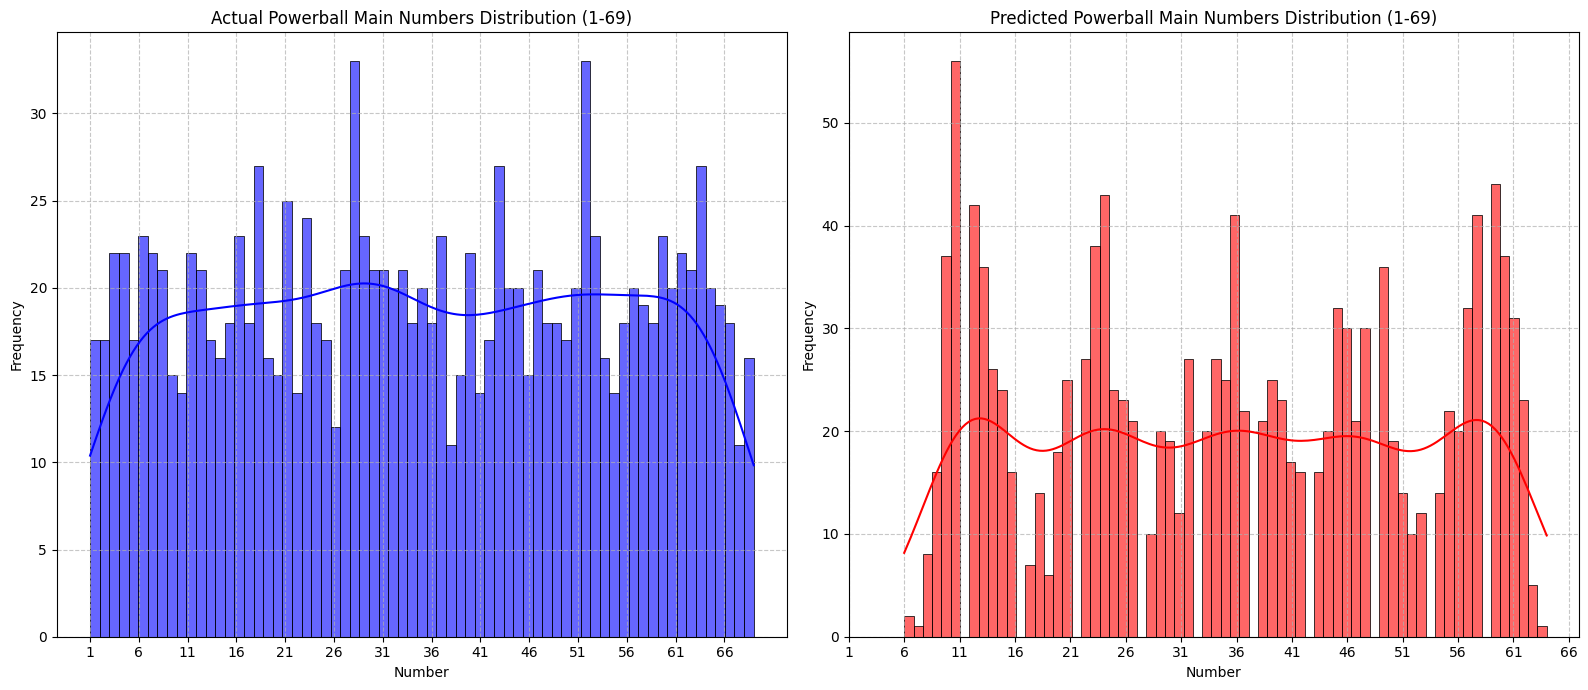

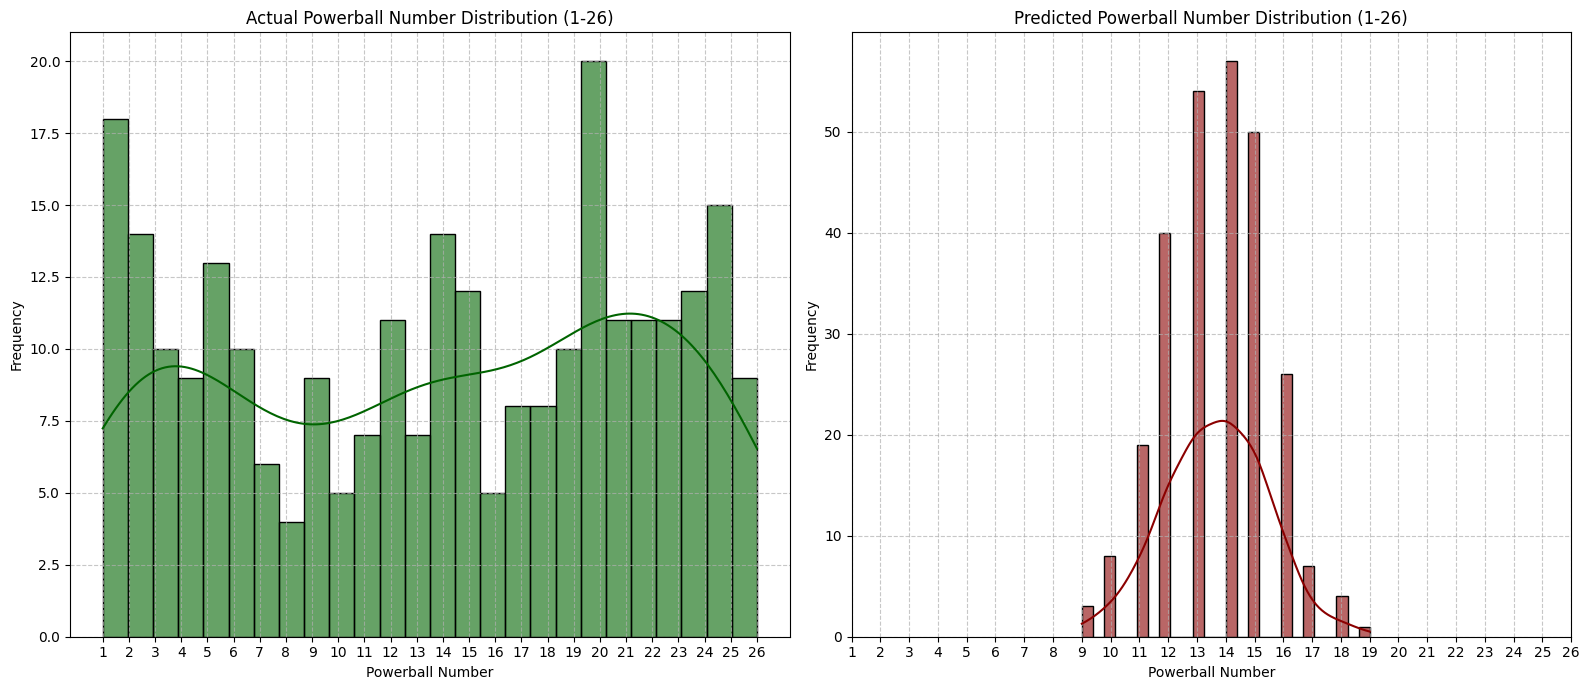

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Powerball Main Numbers Distribution (Predicted vs Actual) ---

plt.figure(figsize=(16, 7))

# Actual Main Numbers
plt.subplot(1, 2, 1)
actual_main_pb_numbers = y_test_np[:, :5].flatten()
sns.histplot(actual_main_pb_numbers, bins=69, kde=True, color='blue', label='Actual', alpha=0.6)
plt.title('Actual Powerball Main Numbers Distribution (1-69)')
plt.xlabel('Number')
plt.ylabel('Frequency')
plt.xticks(range(1, 70, 5))
plt.grid(True, linestyle='--', alpha=0.7)

# Predicted Main Numbers
plt.subplot(1, 2, 2)
predicted_main_pb_numbers = y_pred_rounded[:, :5].flatten()
sns.histplot(predicted_main_pb_numbers, bins=69, kde=True, color='red', label='Predicted', alpha=0.6)
plt.title('Predicted Powerball Main Numbers Distribution (1-69)')
plt.xlabel('Number')
plt.ylabel('Frequency')
plt.xticks(range(1, 70, 5))
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# --- Powerball Number Distribution (Predicted vs Actual) ---

plt.figure(figsize=(16, 7))

# Actual Powerball
plt.subplot(1, 2, 1)
actual_pb_numbers = y_test_np[:, 5]
sns.histplot(actual_pb_numbers, bins=26, kde=True, color='darkgreen', label='Actual', alpha=0.6)
plt.title('Actual Powerball Number Distribution (1-26)')
plt.xlabel('Powerball Number')
plt.ylabel('Frequency')
plt.xticks(range(1, 27))
plt.grid(True, linestyle='--', alpha=0.7)

# Predicted Powerball
plt.subplot(1, 2, 2)
predicted_pb_numbers = y_pred_rounded[:, 5]
sns.histplot(predicted_pb_numbers, bins=26, kde=True, color='darkred', label='Predicted', alpha=0.6)
plt.title('Predicted Powerball Number Distribution (1-26)')
plt.xlabel('Powerball Number')
plt.ylabel('Frequency')
plt.xticks(range(1, 27))
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# Re-create and save Powerball Main Numbers Distribution (Predicted vs Actual) plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.histplot(y_test_np[:, :5].flatten(), bins=69, kde=True, color='blue', label='Actual', alpha=0.6, ax=axes[0])
axes[0].set_title('Actual Powerball Main Numbers Distribution (1-69)')
axes[0].set_xlabel('Number')
axes[0].set_ylabel('Frequency')
axes[0].set_xticks(range(1, 70, 5))
axes[0].grid(True, linestyle='--', alpha=0.7)

sns.histplot(y_pred_rounded[:, :5].flatten(), bins=69, kde=True, color='red', label='Predicted', alpha=0.6, ax=axes[1])
axes[1].set_title('Predicted Powerball Main Numbers Distribution (1-69)')
axes[1].set_xlabel('Number')
axes[1].set_ylabel('Frequency')
axes[1].set_xticks(range(1, 70, 5))
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(os.path.join(pb_graphics_output_path, 'powerball_main_numbers_predicted_vs_actual.png'))
plt.close()
print(f"'powerball_main_numbers_predicted_vs_actual.png' saved to {pb_graphics_output_path}")

# Re-create and save Powerball Number Distribution (Predicted vs Actual) plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.histplot(y_test_np[:, 5], bins=26, kde=True, color='darkgreen', label='Actual', alpha=0.6, ax=axes[0])
axes[0].set_title('Actual Powerball Number Distribution (1-26)')
axes[0].set_xlabel('Powerball Number')
axes[0].set_ylabel('Frequency')
axes[0].set_xticks(range(1, 27))
axes[0].grid(True, linestyle='--', alpha=0.7)

sns.histplot(y_pred_rounded[:, 5], bins=26, kde=True, color='darkred', label='Predicted', alpha=0.6, ax=axes[1])
axes[1].set_title('Predicted Powerball Number Distribution (1-26)')
axes[1].set_xlabel('Powerball Number')
axes[1].set_ylabel('Frequency')
axes[1].set_xticks(range(1, 27))
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(os.path.join(pb_graphics_output_path, 'powerball_number_predicted_vs_actual.png'))
plt.close()
print(f"'powerball_number_predicted_vs_actual.png' saved to {pb_graphics_output_path}")

'powerball_main_numbers_predicted_vs_actual.png' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/PowerBall/Graphics
'powerball_number_predicted_vs_actual.png' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/PowerBall/Graphics


### Visualization: Predicted vs. Actual Lottery Number Distributions (Mega Millions)

Now let's do the same for Mega Millions, comparing the distribution of our predicted numbers against the actual winning numbers.

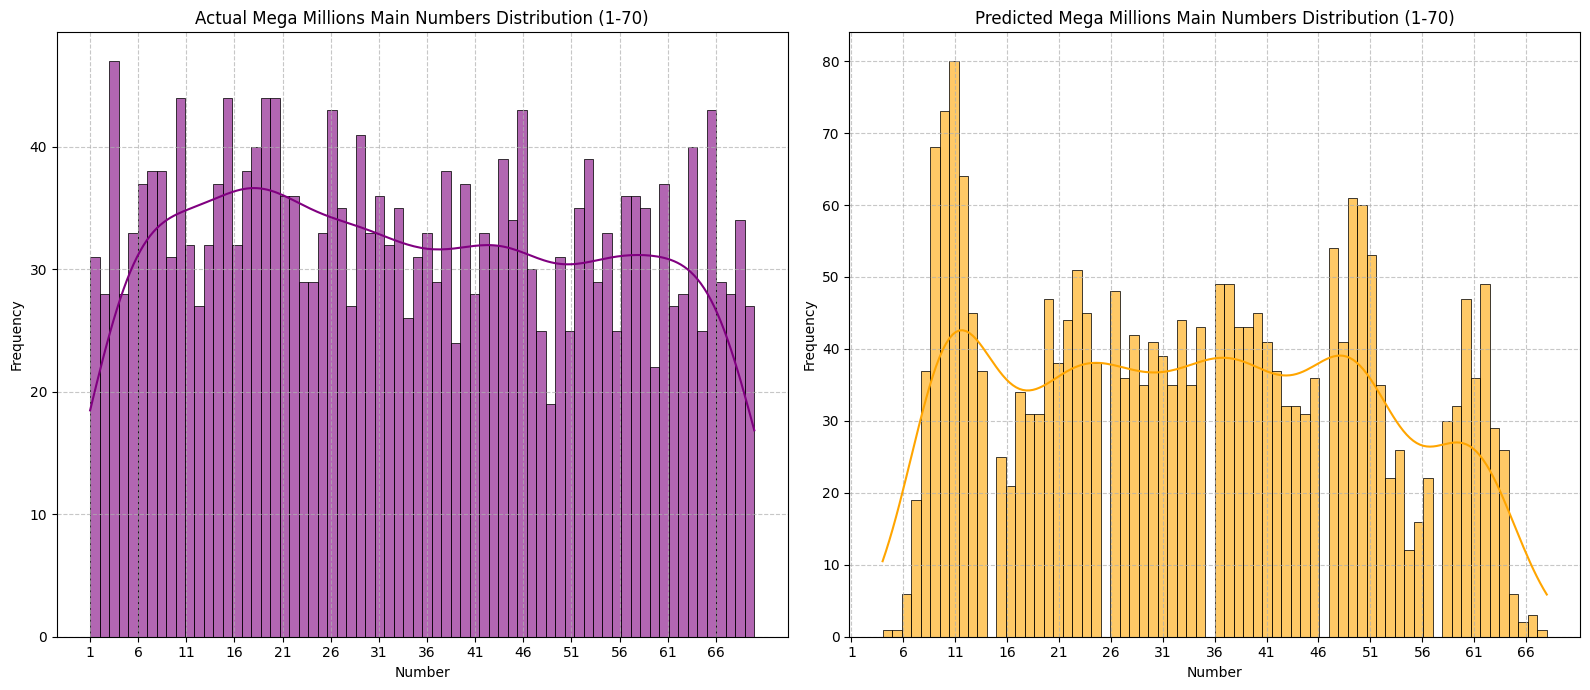

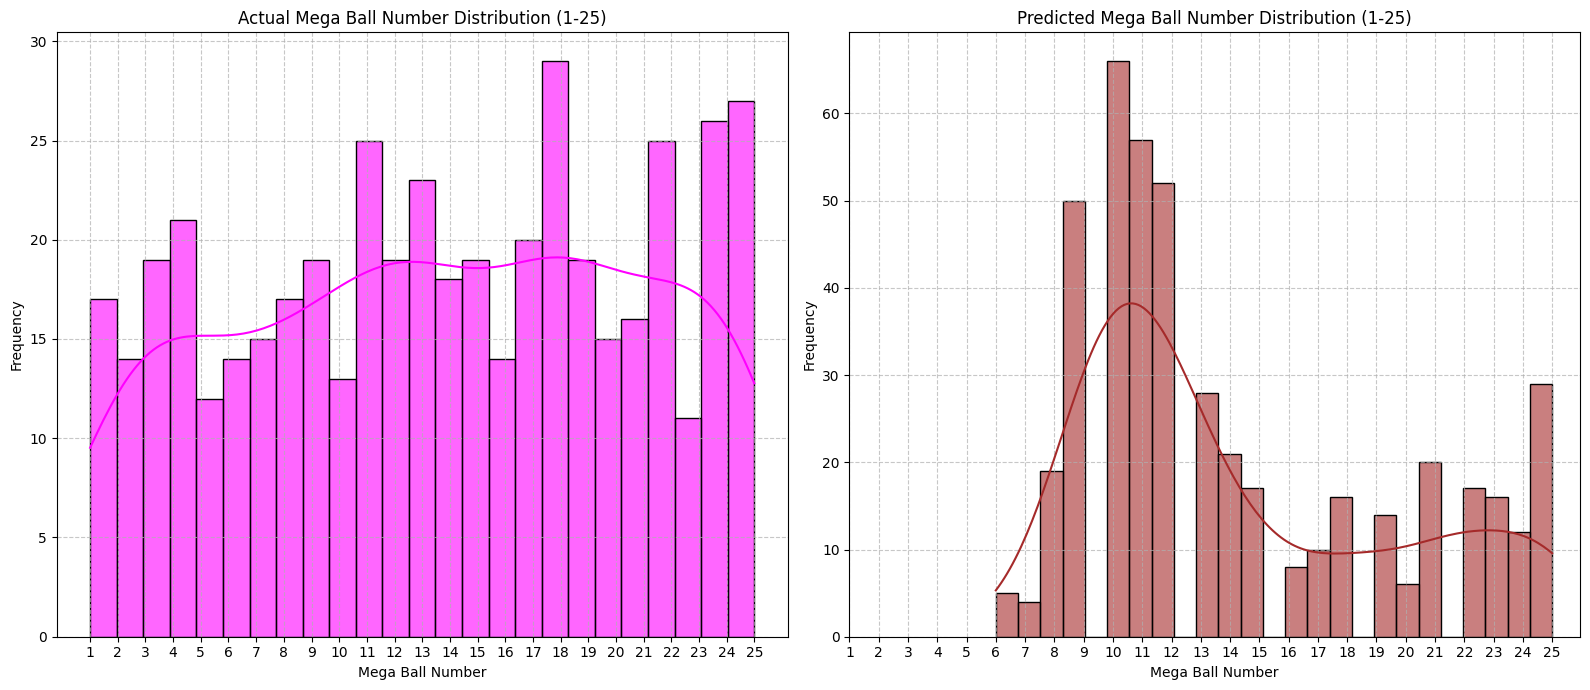

In [ ]:
# --- Mega Millions Main Numbers Distribution (Predicted vs Actual) ---

plt.figure(figsize=(16, 7))

# Actual Main Numbers
plt.subplot(1, 2, 1)
actual_main_mm_numbers = y_mm_test_np[:, :5].flatten()
sns.histplot(actual_main_mm_numbers, bins=70, kde=True, color='purple', label='Actual', alpha=0.6)
plt.title('Actual Mega Millions Main Numbers Distribution (1-70)')
plt.xlabel('Number')
plt.ylabel('Frequency')
plt.xticks(range(1, 71, 5))
plt.grid(True, linestyle='--', alpha=0.7)

# Predicted Main Numbers
plt.subplot(1, 2, 2)
predicted_main_mm_numbers = y_mm_pred_rounded[:, :5].flatten()
sns.histplot(predicted_main_mm_numbers, bins=70, kde=True, color='orange', label='Predicted', alpha=0.6)
plt.title('Predicted Mega Millions Main Numbers Distribution (1-70)')
plt.xlabel('Number')
plt.ylabel('Frequency')
plt.xticks(range(1, 71, 5))
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# --- Mega Ball Number Distribution (Predicted vs Actual) ---

plt.figure(figsize=(16, 7))

# Actual Mega Ball
plt.subplot(1, 2, 1)
actual_mm_numbers = y_mm_test_np[:, 5]
sns.histplot(actual_mm_numbers, bins=25, kde=True, color='magenta', label='Actual', alpha=0.6)
plt.title('Actual Mega Ball Number Distribution (1-25)')
plt.xlabel('Mega Ball Number')
plt.ylabel('Frequency')
plt.xticks(range(1, 26))
plt.grid(True, linestyle='--', alpha=0.7)

# Predicted Mega Ball
plt.subplot(1, 2, 2)
predicted_mm_numbers = y_mm_pred_rounded[:, 5]
sns.histplot(predicted_mm_numbers, bins=25, kde=True, color='brown', label='Predicted', alpha=0.6)
plt.title('Predicted Mega Ball Number Distribution (1-25)')
plt.xlabel('Mega Ball Number')
plt.ylabel('Frequency')
plt.xticks(range(1, 26))
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# Re-create and save Mega Millions Main Numbers Distribution (Predicted vs Actual) plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.histplot(y_mm_test_np[:, :5].flatten(), bins=70, kde=True, color='purple', label='Actual', alpha=0.6, ax=axes[0])
axes[0].set_title('Actual Mega Millions Main Numbers Distribution (1-70)')
axes[0].set_xlabel('Number')
axes[0].set_ylabel('Frequency')
axes[0].set_xticks(range(1, 71, 5))
axes[0].grid(True, linestyle='--', alpha=0.7)

sns.histplot(y_mm_pred_rounded[:, :5].flatten(), bins=70, kde=True, color='orange', label='Predicted', alpha=0.6, ax=axes[1])
axes[1].set_title('Predicted Mega Millions Main Numbers Distribution (1-70)')
axes[1].set_xlabel('Number')
axes[1].set_ylabel('Frequency')
axes[1].set_xticks(range(1, 71, 5))
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(os.path.join(mm_graphics_output_path, 'megamillions_main_numbers_predicted_vs_actual.png'))
plt.close()
print(f"'megamillions_main_numbers_predicted_vs_actual.png' saved to {mm_graphics_output_path}")

# Re-create and save Mega Ball Number Distribution (Predicted vs Actual) plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.histplot(y_mm_test_np[:, 5], bins=25, kde=True, color='magenta', label='Actual', alpha=0.6, ax=axes[0])
axes[0].set_title('Actual Mega Ball Number Distribution (1-25)')
axes[0].set_xlabel('Mega Ball Number')
axes[0].set_ylabel('Frequency')
axes[0].set_xticks(range(1, 26))
axes[0].grid(True, linestyle='--', alpha=0.7)

sns.histplot(y_mm_pred_rounded[:, 5], bins=25, kde=True, color='brown', label='Predicted', alpha=0.6, ax=axes[1])
axes[1].set_title('Predicted Mega Ball Number Distribution (1-25)')
axes[1].set_xlabel('Mega Ball Number')
axes[1].set_ylabel('Frequency')
axes[1].set_xticks(range(1, 26))
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(os.path.join(mm_graphics_output_path, 'megamillions_megaball_number_predicted_vs_actual.png'))
plt.close()
print(f"'megamillions_megaball_number_predicted_vs_actual.png' saved to {mm_graphics_output_path}")

'megamillions_main_numbers_predicted_vs_actual.png' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/Mega_Millions/Graphics
'megamillions_megaball_number_predicted_vs_actual.png' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/Mega_Millions/Graphics


### Multivariate Analysis: Covariance Heatmaps (Powerball)

Let's analyze the relationships between the Powerball numbers by visualizing their covariance matrix using Plotly. This can reveal if certain numbers tend to appear together or vary in similar ways.

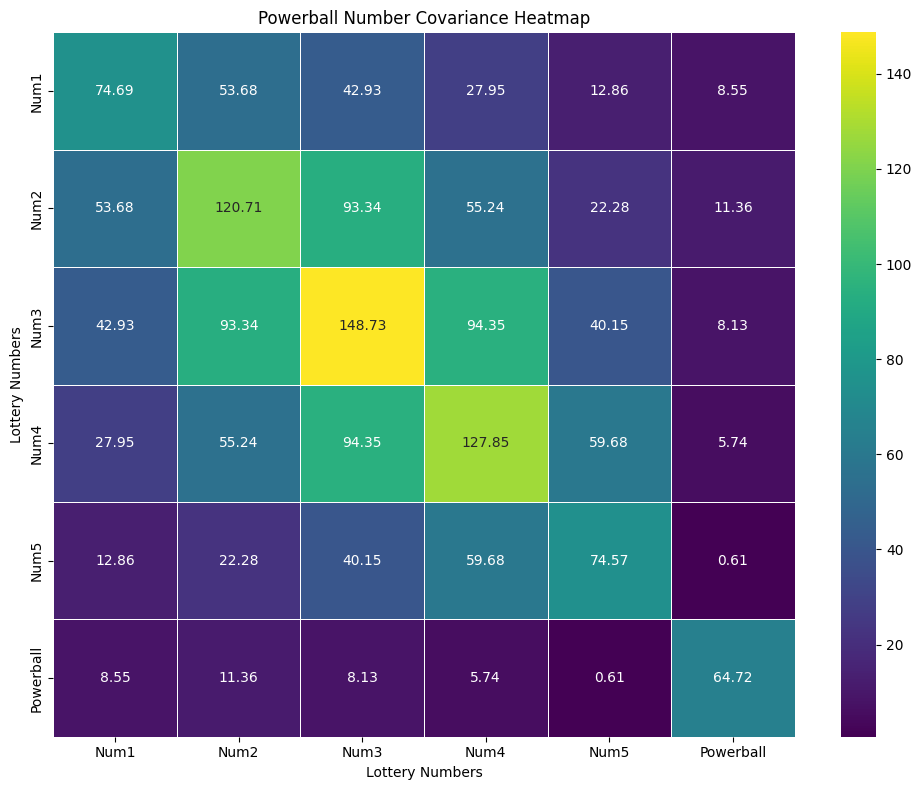

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the number columns for Powerball from the test set (actual values)
pb_numbers_for_covariance = y_test[['Num1', 'Num2', 'Num3', 'Num4', 'Num5', 'Powerball']]

# Calculate the covariance matrix
pb_covariance_matrix = pb_numbers_for_covariance.cov()

# Create a Matplotlib/Seaborn heatmap for Powerball covariance
plt.figure(figsize=(10, 8))
sns.heatmap(
    pb_covariance_matrix,
    annot=True,
    cmap='viridis',
    fmt=".2f", # Format annotation to two decimal places
    linewidths=.5
)
plt.title('Powerball Number Covariance Heatmap')
plt.xlabel('Lottery Numbers')
plt.ylabel('Lottery Numbers')
plt.tight_layout()
plt.show()

In [ ]:
import sys
!{sys.executable} -m pip install -U plotly

In [ ]:
# Save the Powerball covariance matrix DataFrame
pb_covariance_matrix.to_csv(os.path.join(pb_data_output_path, 'powerball_covariance_matrix.csv'))
print(f"'powerball_covariance_matrix.csv' saved to {pb_data_output_path}")

# Save the Powerball covariance heatmap using plt.savefig
plt.figure(figsize=(10, 8))
sns.heatmap(
    pb_covariance_matrix,
    annot=True,
    cmap='viridis',
    fmt=".2f",
    linewidths=.5
)
plt.title('Powerball Number Covariance Heatmap')
plt.xlabel('Lottery Numbers')
plt.ylabel('Lottery Numbers')
plt.tight_layout()
plt.savefig(os.path.join(pb_graphics_output_path, 'powerball_covariance_heatmap.png'))
plt.close() # Close the plot to prevent it from displaying twice
print(f"'powerball_covariance_heatmap.png' saved to {pb_graphics_output_path}")

'powerball_covariance_matrix.csv' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/PowerBall/Data
'powerball_covariance_heatmap.png' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/PowerBall/Graphics


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Assuming y_test, pb_data_output_path, pb_graphics_output_path are defined
pb_numbers_for_covariance = y_test[['Num1', 'Num2', 'Num3', 'Num4', 'Num5', 'Powerball']]
pb_covariance_matrix = pb_numbers_for_covariance.cov()

# Save the Powerball covariance matrix DataFrame
pb_covariance_matrix.to_csv(os.path.join(pb_data_output_path, 'powerball_covariance_matrix.csv'))
print(f"'powerball_covariance_matrix.csv' saved to {pb_data_output_path}")

# Create and save Powerball covariance heatmap using Matplotlib/Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(
    pb_covariance_matrix,
    annot=True,
    cmap='viridis',
    fmt=".2f",
    linewidths=.5
)
plt.title('Powerball Number Covariance Heatmap')
plt.xlabel('Lottery Numbers')
plt.ylabel('Lottery Numbers')
plt.tight_layout()
plt.savefig(os.path.join(pb_graphics_output_path, 'powerball_covariance_heatmap.png'))
plt.close() # Close the plot to prevent it from displaying twice
print(f"'powerball_covariance_heatmap.png' saved to {pb_graphics_output_path}")

'powerball_covariance_matrix.csv' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/PowerBall/Data
'powerball_covariance_heatmap.png' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/PowerBall/Graphics


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Assuming y_test, pb_data_output_path, pb_graphics_output_path are defined
pb_numbers_for_covariance = y_test[['Num1', 'Num2', 'Num3', 'Num4', 'Num5', 'Powerball']]
pb_covariance_matrix = pb_numbers_for_covariance.cov()

# Save the Powerball covariance matrix DataFrame
pb_covariance_matrix.to_csv(os.path.join(pb_data_output_path, 'powerball_covariance_matrix.csv'))
print(f"'powerball_covariance_matrix.csv' saved to {pb_data_output_path}")

# Create and save Powerball covariance heatmap using Matplotlib/Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(
    pb_covariance_matrix,
    annot=True,
    cmap='viridis',
    fmt=".2f",
    linewidths=.5
)
plt.title('Powerball Number Covariance Heatmap')
plt.xlabel('Lottery Numbers')
plt.ylabel('Lottery Numbers')
plt.tight_layout()
plt.savefig(os.path.join(pb_graphics_output_path, 'powerball_covariance_heatmap.png'))
plt.close() # Close the plot to prevent it from displaying twice
print(f"'powerball_covariance_heatmap.png' saved to {pb_graphics_output_path}")

'powerball_covariance_matrix.csv' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/PowerBall/Data
'powerball_covariance_heatmap.png' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/PowerBall/Graphics


### Multivariate Analysis: Covariance Heatmaps (Mega Millions)

Similarly, let's look at the covariance matrix for the Mega Millions numbers.

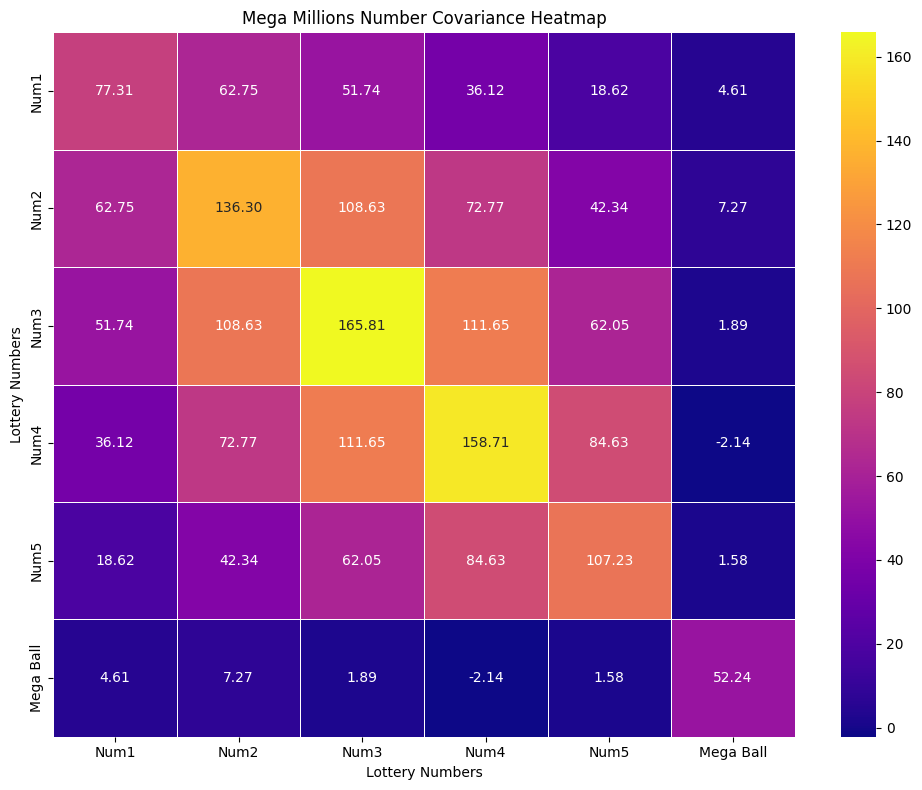

In [ ]:
# Select the number columns for Mega Millions from the test set (actual values)
mm_numbers_for_covariance = y_mm_test[['Num1', 'Num2', 'Num3', 'Num4', 'Num5', 'Mega Ball']]

# Calculate the covariance matrix
mm_covariance_matrix = mm_numbers_for_covariance.cov()

# Create a Matplotlib/Seaborn heatmap for Mega Millions covariance
plt.figure(figsize=(10, 8))
sns.heatmap(
    mm_covariance_matrix,
    annot=True,
    cmap='plasma',
    fmt=".2f", # Format annotation to two decimal places
    linewidths=.5
)
plt.title('Mega Millions Number Covariance Heatmap')
plt.xlabel('Lottery Numbers')
plt.ylabel('Lottery Numbers')
plt.tight_layout()
plt.show()

In [ ]:
# Save the Mega Millions covariance matrix DataFrame
mm_covariance_matrix.to_csv(os.path.join(mm_data_output_path, 'megamillions_covariance_matrix.csv'))
print(f"'megamillions_covariance_matrix.csv' saved to {mm_data_output_path}")

# Save the Mega Millions covariance heatmap using plt.savefig
plt.figure(figsize=(10, 8))
sns.heatmap(
    mm_covariance_matrix,
    annot=True,
    cmap='plasma',
    fmt=".2f",
    linewidths=.5
)
plt.title('Mega Millions Number Covariance Heatmap')
plt.xlabel('Lottery Numbers')
plt.ylabel('Lottery Numbers')
plt.tight_layout()
plt.savefig(os.path.join(mm_graphics_output_path, 'megamillions_covariance_heatmap.png'))
plt.close() # Close the plot to prevent it from displaying twice
print(f"'megamillions_covariance_heatmap.png' saved to {mm_graphics_output_path}")

'megamillions_covariance_matrix.csv' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/Mega_Millions/Data
'megamillions_covariance_heatmap.png' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/Mega_Millions/Graphics


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Assuming y_mm_test, mm_data_output_path, mm_graphics_output_path are defined
mm_numbers_for_covariance = y_mm_test[['Num1', 'Num2', 'Num3', 'Num4', 'Num5', 'Mega Ball']]
mm_covariance_matrix = mm_numbers_for_covariance.cov()

# Save the Mega Millions covariance matrix DataFrame
mm_covariance_matrix.to_csv(os.path.join(mm_data_output_path, 'megamillions_covariance_matrix.csv'))
print(f"'megamillions_covariance_matrix.csv' saved to {mm_data_output_path}")

# Create and save Mega Millions covariance heatmap using Matplotlib/Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(
    mm_covariance_matrix,
    annot=True,
    cmap='plasma',
    fmt=".2f",
    linewidths=.5
)
plt.title('Mega Millions Number Covariance Heatmap')
plt.xlabel('Lottery Numbers')
plt.ylabel('Lottery Numbers')
plt.tight_layout()
plt.savefig(os.path.join(mm_graphics_output_path, 'megamillions_covariance_heatmap.png'))
plt.close() # Close the plot to prevent it from displaying twice
print(f"'megamillions_covariance_heatmap.png' saved to {mm_graphics_output_path}")

'megamillions_covariance_matrix.csv' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/Mega_Millions/Data
'megamillions_covariance_heatmap.png' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/Mega_Millions/Graphics


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Assuming y_mm_test, mm_data_output_path, mm_graphics_output_path are defined
mm_numbers_for_covariance = y_mm_test[['Num1', 'Num2', 'Num3', 'Num4', 'Num5', 'Mega Ball']]
mm_covariance_matrix = mm_numbers_for_covariance.cov()

# Save the Mega Millions covariance matrix DataFrame
mm_covariance_matrix.to_csv(os.path.join(mm_data_output_path, 'megamillions_covariance_matrix.csv'))
print(f"'megamillions_covariance_matrix.csv' saved to {mm_data_output_path}")

# Create and save Mega Millions covariance heatmap using Matplotlib/Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(
    mm_covariance_matrix,
    annot=True,
    cmap='plasma',
    fmt=".2f",
    linewidths=.5
)
plt.title('Mega Millions Number Covariance Heatmap')
plt.xlabel('Lottery Numbers')
plt.ylabel('Lottery Numbers')
plt.tight_layout()
plt.savefig(os.path.join(mm_graphics_output_path, 'megamillions_covariance_heatmap.png'))
plt.close() # Close the plot to prevent it from displaying twice
print(f"'megamillions_covariance_heatmap.png' saved to {mm_graphics_output_path}")

'megamillions_covariance_matrix.csv' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/Mega_Millions/Data
'megamillions_covariance_heatmap.png' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/Mega_Millions/Graphics


### Visualizing Model Fitness (Statistical Noise) - Residuals for Powerball

To understand how well our RandomForestRegressor model fits the Powerball data, we can examine the distribution of residuals (the difference between the actual and predicted numbers). Ideally, residuals should be centered around zero and show no obvious patterns.

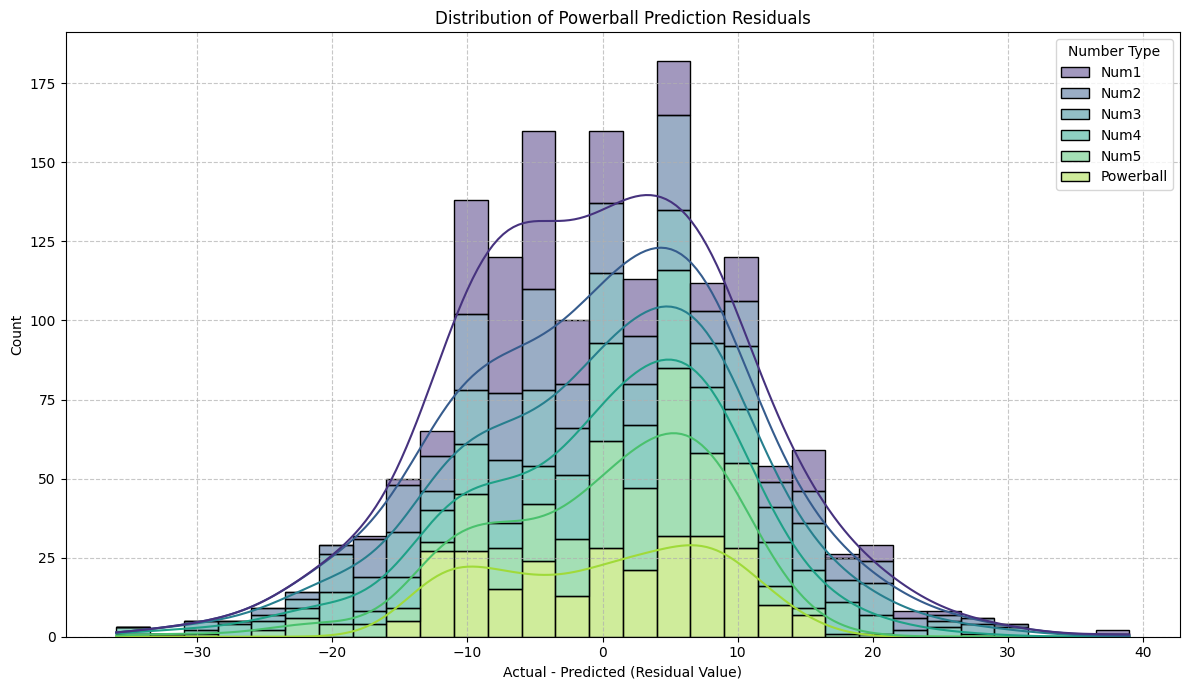

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals for Powerball
pb_residuals = pd.DataFrame(y_test_np - y_pred_rounded, columns=y_test.columns)

# Melt the DataFrame to plot all residuals in a single histogram with different colors
pb_residuals_melted = pb_residuals.melt(var_name='Number Type', value_name='Residual')

plt.figure(figsize=(12, 7))
sns.histplot(data=pb_residuals_melted, x='Residual', hue='Number Type', multiple='stack', bins=30, kde=True, palette='viridis')
plt.title('Distribution of Powerball Prediction Residuals')
plt.xlabel('Actual - Predicted (Residual Value)')
plt.ylabel('Count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Save the Powerball residuals DataFrame
pb_residuals.to_csv(os.path.join(pb_data_output_path, 'powerball_residuals.csv'), index=False)
print(f"'powerball_residuals.csv' saved to {pb_data_output_path}")

# Save the Powerball prediction residuals histogram
plt.figure(figsize=(12, 7))
sns.histplot(data=pb_residuals_melted, x='Residual', hue='Number Type', multiple='stack', bins=30, kde=True, palette='viridis')
plt.title('Distribution of Powerball Prediction Residuals')
plt.xlabel('Actual - Predicted (Residual Value)')
plt.ylabel('Count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(pb_graphics_output_path, 'powerball_prediction_residuals_histogram.png'))
plt.close() # Close the plot to prevent it from displaying twice
print(f"'powerball_prediction_residuals_histogram.png' saved to {pb_graphics_output_path}")

'powerball_residuals.csv' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/PowerBall/Data
'powerball_prediction_residuals_histogram.png' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/PowerBall/Graphics


In [ ]:
# Re-create and save Powerball prediction residuals histogram
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import numpy as np

# Assuming y_test_np, y_pred_rounded, y_test.columns, pb_data_output_path, pb_graphics_output_path are defined
pb_residuals = pd.DataFrame(y_test_np - y_pred_rounded, columns=y_test.columns)
pb_residuals_melted = pb_residuals.melt(var_name='Number Type', value_name='Residual')

plt.figure(figsize=(12, 7))
sns.histplot(data=pb_residuals_melted, x='Residual', hue='Number Type', multiple='stack', bins=30, kde=True, palette='viridis')
plt.title('Distribution of Powerball Prediction Residuals')
plt.xlabel('Actual - Predicted (Residual Value)')
plt.ylabel('Count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

pb_residuals.to_csv(os.path.join(pb_data_output_path, 'powerball_residuals.csv'), index=False)
print(f"'powerball_residuals.csv' saved to {pb_data_output_path}")

plt.savefig(os.path.join(pb_graphics_output_path, 'powerball_prediction_residuals_histogram.png'))
plt.close() # Close the plot to prevent it from displaying twice
print(f"'powerball_prediction_residuals_histogram.png' saved to {pb_graphics_output_path}")

'powerball_residuals.csv' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/PowerBall/Data
'powerball_prediction_residuals_histogram.png' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/PowerBall/Graphics


In [ ]:
# Save the Powerball residuals DataFrame
pb_residuals.to_csv(os.path.join(pb_data_output_path, 'powerball_residuals.csv'), index=False)
print(f"'powerball_residuals.csv' saved to {pb_data_output_path}")

# Save the Powerball prediction residuals histogram
plt.figure(figsize=(12, 7))
sns.histplot(data=pb_residuals_melted, x='Residual', hue='Number Type', multiple='stack', bins=30, kde=True, palette='viridis')
plt.title('Distribution of Powerball Prediction Residuals')
plt.xlabel('Actual - Predicted (Residual Value)')
plt.ylabel('Count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(pb_graphics_output_path, 'powerball_prediction_residuals_histogram.png'))
plt.close() # Close the plot to prevent it from displaying twice
print(f"'powerball_prediction_residuals_histogram.png' saved to {pb_graphics_output_path}")

'powerball_residuals.csv' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/PowerBall/Data
'powerball_prediction_residuals_histogram.png' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/PowerBall/Graphics


### Visualizing Model Fitness (Statistical Noise) - Residuals for Mega Millions

Let's do the same for the Mega Millions model to evaluate its fit.

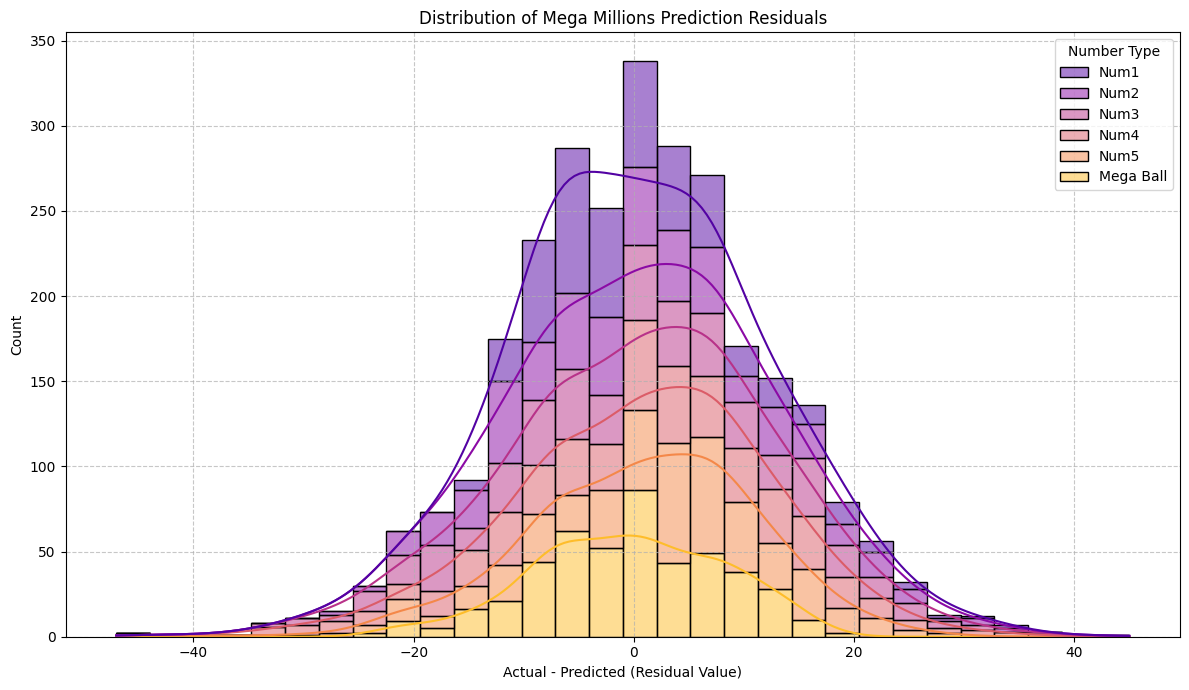

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals for Mega Millions
mm_residuals = pd.DataFrame(y_mm_test_np - y_mm_pred_rounded, columns=y_mm_test.columns)

# Melt the DataFrame to plot all residuals in a single histogram with different colors
mm_residuals_melted = mm_residuals.melt(var_name='Number Type', value_name='Residual')

plt.figure(figsize=(12, 7))
sns.histplot(data=mm_residuals_melted, x='Residual', hue='Number Type', multiple='stack', bins=30, kde=True, palette='plasma')
plt.title('Distribution of Mega Millions Prediction Residuals')
plt.xlabel('Actual - Predicted (Residual Value)')
plt.ylabel('Count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Save the Mega Millions residuals DataFrame
mm_residuals.to_csv(os.path.join(mm_data_output_path, 'megamillions_residuals.csv'), index=False)
print(f"'megamillions_residuals.csv' saved to {mm_data_output_path}")

# Save the Mega Millions prediction residuals histogram
plt.figure(figsize=(12, 7))
sns.histplot(data=mm_residuals_melted, x='Residual', hue='Number Type', multiple='stack', bins=30, kde=True, palette='plasma')
plt.title('Distribution of Mega Millions Prediction Residuals')
plt.xlabel('Actual - Predicted (Residual Value)')
plt.ylabel('Count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(mm_graphics_output_path, 'megamillions_prediction_residuals_histogram.png'))
plt.close() # Close the plot to prevent it from displaying twice
print(f"'megamillions_prediction_residuals_histogram.png' saved to {mm_graphics_output_path}")

'megamillions_residuals.csv' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/Mega_Millions/Data
'megamillions_prediction_residuals_histogram.png' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/Mega_Millions/Graphics


In [ ]:
# Re-create and save Mega Millions prediction residuals histogram
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import numpy as np

# Assuming y_mm_test_np, y_mm_pred_rounded, y_mm_test.columns, mm_data_output_path, mm_graphics_output_path are defined
mm_residuals = pd.DataFrame(y_mm_test_np - y_mm_pred_rounded, columns=y_mm_test.columns)
mm_residuals_melted = mm_residuals.melt(var_name='Number Type', value_name='Residual')

plt.figure(figsize=(12, 7))
sns.histplot(data=mm_residuals_melted, x='Residual', hue='Number Type', multiple='stack', bins=30, kde=True, palette='plasma')
plt.title('Distribution of Mega Millions Prediction Residuals')
plt.xlabel('Actual - Predicted (Residual Value)')
plt.ylabel('Count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

mm_residuals.to_csv(os.path.join(mm_data_output_path, 'megamillions_residuals.csv'), index=False)
print(f"'megamillions_residuals.csv' saved to {mm_data_output_path}")

plt.savefig(os.path.join(mm_graphics_output_path, 'megamillions_prediction_residuals_histogram.png'))
plt.close() # Close the plot to prevent it from displaying twice
print(f"'megamillions_prediction_residuals_histogram.png' saved to {mm_graphics_output_path}")

'megamillions_residuals.csv' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/Mega_Millions/Data
'megamillions_prediction_residuals_histogram.png' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/Mega_Millions/Graphics


In [ ]:
# Save the Mega Millions residuals DataFrame
mm_residuals.to_csv(os.path.join(mm_data_output_path, 'megamillions_residuals.csv'), index=False)
print(f"'megamillions_residuals.csv' saved to {mm_data_output_path}")

# Save the Mega Millions prediction residuals histogram
plt.figure(figsize=(12, 7))
sns.histplot(data=mm_residuals_melted, x='Residual', hue='Number Type', multiple='stack', bins=30, kde=True, palette='plasma')
plt.title('Distribution of Mega Millions Prediction Residuals')
plt.xlabel('Actual - Predicted (Residual Value)')
plt.ylabel('Count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(mm_graphics_output_path, 'megamillions_prediction_residuals_histogram.png'))
plt.close() # Close the plot to prevent it from displaying twice
print(f"'megamillions_prediction_residuals_histogram.png' saved to {mm_graphics_output_path}")

'megamillions_residuals.csv' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/Mega_Millions/Data
'megamillions_prediction_residuals_histogram.png' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/Mega_Millions/Graphics


### Model Evaluation Strategy

Evaluating a lottery prediction model is unique because traditional regression metrics like Mean Squared Error (MSE) or R-squared, while useful, don't directly tell us how many winning numbers were predicted correctly. Since the probability of winning the lottery is extremely low, predicting the exact set of 6 numbers is highly improbable.

Instead, we might consider evaluation metrics that align more with partial success, such as:

1.  **Number of Exact Matches:** How many main numbers and the Powerball number were predicted correctly in a single draw.
2.  **Accuracy per Number:** The percentage of times each individual number (Num1-Num5, Powerball) was predicted correctly.
3.  **Top N Predictions:** For each main number slot, if we predict the top N most likely numbers, how often does the actual number fall within that set?
4.  **Distribution Comparison:** How well does the distribution of predicted numbers match the historical distribution of winning numbers?

For now, we've made the predictions. In the next step, we can calculate some of these more specific evaluation metrics.

### Predicting Next Possible Winning Tickets (Powerball & Mega Millions)

To generate the 'Top 10' predictions, we will leverage the individual trees within our `RandomForestRegressor` models. Each tree in the forest provides a slightly different prediction. By collecting these, rounding them to integer values, clipping them to valid lottery ranges, and then counting the most frequent unique combinations, we can derive a set of 'most likely' tickets according to our model.

It's crucial to remember that lottery outcomes are fundamentally random, and these predictions are purely statistical interpretations based on historical patterns and the model's learning. They do not guarantee winning.

### Time Series Modeling: ARIMA for Powerball and Mega Millions

While traditional regression models like Random Forests can capture complex relationships, time series models like ARIMA (AutoRegressive Integrated Moving Average) are specifically designed for forecasting data points in a series where there is a dependency between an observation and previous observations.

However, it's crucial to acknowledge that lottery numbers are generally considered random, and strong autocorrelation (patterns over time) is unlikely to exist in a way that would allow for accurate predictions of specific numbers. We will apply ARIMA to see if any such temporal patterns can be detected and leveraged, particularly for individual numbers like the Powerball or Mega Ball.

In [ ]:
# Install pmdarima for auto_arima functionality
import sys
!{sys.executable} -m pip install pmdarima

#### Powerball ARIMA Model

In [ ]:
import pmdarima as pm

# Prepare Powerball data for ARIMA
pb_arima_data = df_powerball_sorted[['Draw Date', 'Powerball']].set_index('Draw Date')
pb_arima_data = pb_arima_data.asfreq('D') # Ensure daily frequency, fill missing dates with NaNs
pb_arima_data['Powerball'] = pb_arima_data['Powerball'].fillna(method='ffill') # Forward fill NaNs for simplicity

# Split data into training and testing sets
# Use a similar split point as before, or define a new one for time series
train_size_pb = int(len(pb_arima_data) * 0.8)
pb_train, pb_test = pb_arima_data.iloc[:train_size_pb], pb_arima_data.iloc[train_size_pb:]

print(f"Powerball ARIMA training data shape: {pb_train.shape}")
print(f"Powerball ARIMA testing data shape: {pb_test.shape}")

# Fit auto_arima model
# This function searches for the best ARIMA model based on AIC or BIC criteria
pb_model_arima = pm.auto_arima(pb_train['Powerball'], seasonal=False, suppress_warnings=True, stepwise=True,
                             error_action='ignore', max_p=5, max_d=5, max_q=5, trace=True)

print("\nARIMA model summary for Powerball:")
print(pb_model_arima.summary())

# Make predictions
pb_predictions_arima = pb_model_arima.predict(n_periods=len(pb_test))
pb_predictions_arima = np.round(pb_predictions_arima).astype(int)

# Ensure predictions are within valid Powerball range (1-26)
pb_predictions_arima = np.clip(pb_predictions_arima, 1, 26)

# Add predictions to the test DataFrame for easy comparison
pb_test['Predicted_Powerball_ARIMA'] = pb_predictions_arima.values

print("\nFirst 5 Powerball actual vs. ARIMA predictions:")
print(pb_test[['Powerball', 'Predicted_Powerball_ARIMA']].head())

/tmp/ipykernel_35991/3063386195.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  pb_arima_data['Powerball'] = pb_arima_data['Powerball'].fillna(method='ffill') # Forward fill NaNs for simplicity


Powerball ARIMA training data shape: (3086, 1)
Powerball ARIMA testing data shape: (772, 1)
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=10.32 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=25702.614, Time=0.13 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=20021.389, Time=0.48 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=22942.744, Time=1.94 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=20017.651, Time=1.36 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=19976.322, Time=0.64 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=19825.364, Time=1.20 sec
 ARIMA(5,0,0)(0,0,0)[0]             : AIC=19717.895, Time=1.40 sec
 ARIMA(5,0,1)(0,0,0)[0]             : AIC=inf, Time=6.13 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=inf, Time=7.32 sec
 ARIMA(5,0,0)(0,0,0)[0] intercept   : AIC=19388.259, Time=1.58 sec
 ARIMA(4,0,0)(0,0,0)[0] intercept   : AIC=19399.972, Time=1.18 sec
 ARIMA(5,0,1)(0,0,0)[0] intercept   : AIC=19382.182, Time=8.64 sec
 ARIMA(4,0,

/tmp/ipykernel_35991/3063386195.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pb_test['Predicted_Powerball_ARIMA'] = pb_predictions_arima.values


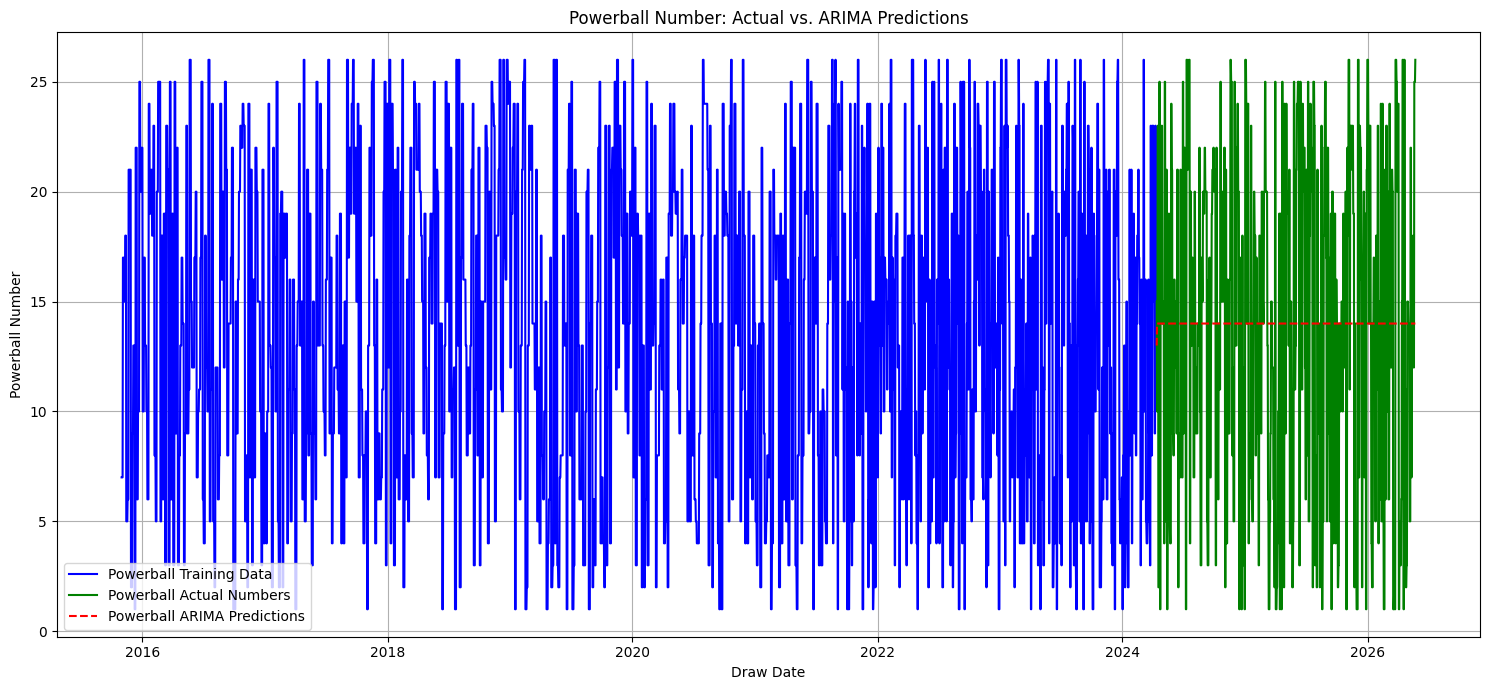

'powerball_arima_predictions.png' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/PowerBall/Graphics

Powerball ARIMA prediction accuracy (exact match): 4.53%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize Powerball ARIMA predictions vs actuals
plt.figure(figsize=(15, 7))
plt.plot(pb_train.index, pb_train['Powerball'], label='Powerball Training Data', color='blue')
plt.plot(pb_test.index, pb_test['Powerball'], label='Powerball Actual Numbers', color='green')
plt.plot(pb_test.index, pb_test['Predicted_Powerball_ARIMA'], label='Powerball ARIMA Predictions', color='red', linestyle='--')
plt.title('Powerball Number: Actual vs. ARIMA Predictions')
plt.xlabel('Draw Date')
plt.ylabel('Powerball Number')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Save the plot
plt.savefig(os.path.join(pb_graphics_output_path, 'powerball_arima_predictions.png'))
plt.close()
print(f"'powerball_arima_predictions.png' saved to {pb_graphics_output_path}")

# Evaluate ARIMA for Powerball (similar to RandomForestRegressor)
pb_arima_matches = 0
for i in range(len(pb_test)):
    if pb_test['Powerball'].iloc[i] == pb_test['Predicted_Powerball_ARIMA'].iloc[i]:
        pb_arima_matches += 1

pb_arima_accuracy = pb_arima_matches / len(pb_test)
print(f"\nPowerball ARIMA prediction accuracy (exact match): {pb_arima_accuracy:.2%}")

#### Mega Millions ARIMA Model

In [ ]:
# Prepare Mega Millions data for ARIMA
mm_arima_data = df_megamillions.sort_values(by='Draw Date')[['Draw Date', 'Mega Ball']].set_index('Draw Date')
mm_arima_data = mm_arima_data.asfreq('D') # Ensure daily frequency
mm_arima_data['Mega Ball'] = mm_arima_data['Mega Ball'].fillna(method='ffill') # Forward fill NaNs for simplicity

# Split data into training and testing sets
train_size_mm = int(len(mm_arima_data) * 0.8)
mm_train, mm_test = mm_arima_data.iloc[:train_size_mm], mm_arima_data.iloc[train_size_mm:]

print(f"Mega Millions ARIMA training data shape: {mm_train.shape}")
print(f"Mega Millions ARIMA testing data shape: {mm_test.shape}")

# Fit auto_arima model
mm_model_arima = pm.auto_arima(mm_train['Mega Ball'], seasonal=False, suppress_warnings=True, stepwise=True,
                             error_action='ignore', max_p=5, max_d=5, max_q=5, trace=True)

print("\nARIMA model summary for Mega Millions:")
print(mm_model_arima.summary())

# Make predictions
mm_predictions_arima = mm_model_arima.predict(n_periods=len(mm_test))
mm_predictions_arima = np.round(mm_predictions_arima).astype(int)

# Ensure predictions are within valid Mega Ball range (1-25)
mm_predictions_arima = np.clip(mm_predictions_arima, 1, 25)

# Add predictions to the test DataFrame for easy comparison
mm_test['Predicted_Mega_Ball_ARIMA'] = mm_predictions_arima.values

print("\nFirst 5 Mega Millions actual vs. ARIMA predictions:")
print(mm_test[['Mega Ball', 'Predicted_Mega_Ball_ARIMA']].head())

/tmp/ipykernel_35991/3230406899.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  mm_arima_data['Mega Ball'] = mm_arima_data['Mega Ball'].fillna(method='ffill') # Forward fill NaNs for simplicity


Mega Millions ARIMA training data shape: (6547, 1)
Mega Millions ARIMA testing data shape: (1637, 1)
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=45692.562, Time=18.89 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=46895.449, Time=0.15 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=46897.449, Time=0.27 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=46897.449, Time=0.62 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=46893.450, Time=0.13 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=7.85 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=46901.449, Time=2.05 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=45524.437, Time=10.99 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=45534.007, Time=9.99 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=45517.713, Time=19.50 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=45505.354, Time=16.75 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=45955.666, Time=1.71 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=25

/tmp/ipykernel_35991/3230406899.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mm_test['Predicted_Mega_Ball_ARIMA'] = mm_predictions_arima.values


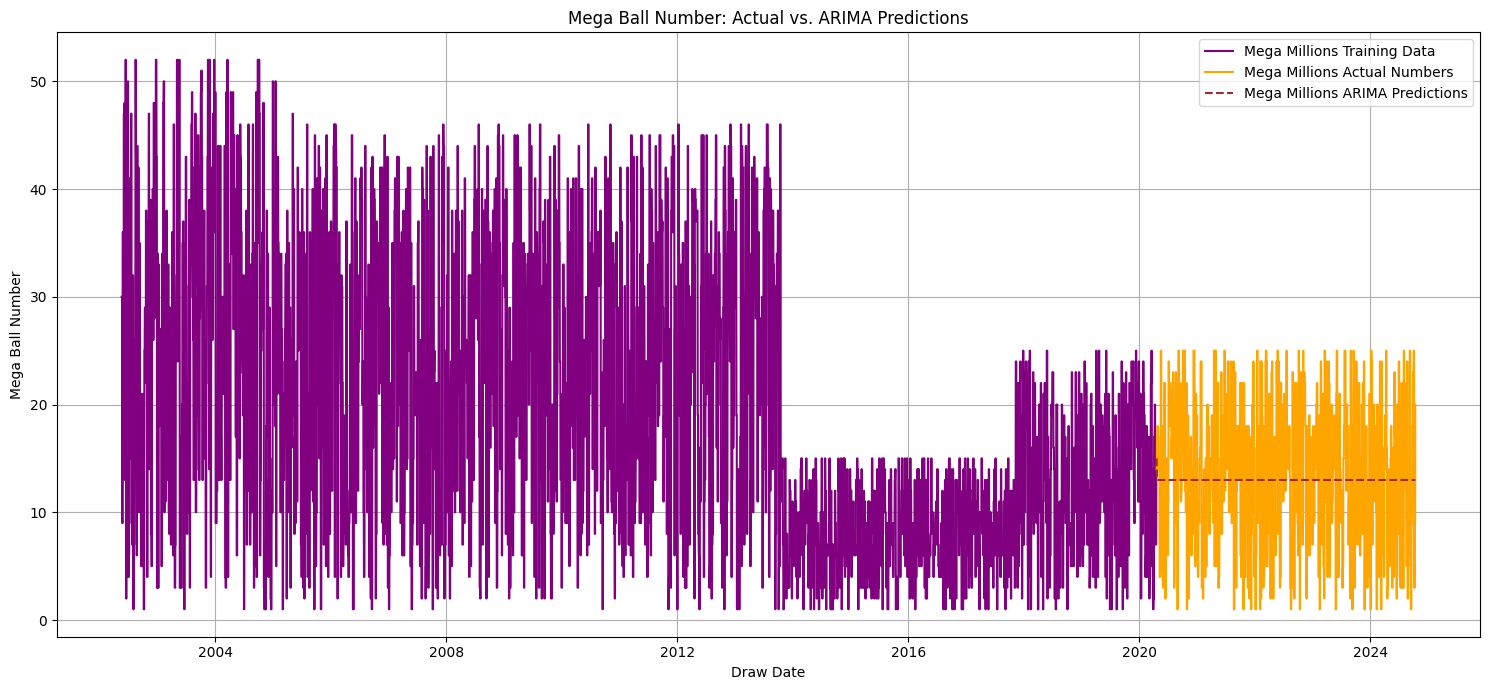

'megamillions_arima_predictions.png' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/Mega_Millions/Graphics

Mega Ball ARIMA prediction accuracy (exact match): 5.07%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize Mega Millions ARIMA predictions vs actuals
plt.figure(figsize=(15, 7))
plt.plot(mm_train.index, mm_train['Mega Ball'], label='Mega Millions Training Data', color='purple')
plt.plot(mm_test.index, mm_test['Mega Ball'], label='Mega Millions Actual Numbers', color='orange')
plt.plot(mm_test.index, mm_test['Predicted_Mega_Ball_ARIMA'], label='Mega Millions ARIMA Predictions', color='brown', linestyle='--')
plt.title('Mega Ball Number: Actual vs. ARIMA Predictions')
plt.xlabel('Draw Date')
plt.ylabel('Mega Ball Number')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Save the plot
plt.savefig(os.path.join(mm_graphics_output_path, 'megamillions_arima_predictions.png'))
plt.close()
print(f"'megamillions_arima_predictions.png' saved to {mm_graphics_output_path}")

# Evaluate ARIMA for Mega Millions
mm_arima_matches = 0
for i in range(len(mm_test)):
    if mm_test['Mega Ball'].iloc[i] == mm_test['Predicted_Mega_Ball_ARIMA'].iloc[i]:
        mm_arima_matches += 1

mm_arima_accuracy = mm_arima_matches / len(mm_test)
print(f"\nMega Ball ARIMA prediction accuracy (exact match): {mm_arima_accuracy:.2%}")

### Interpretation of ARIMA Results

As observed from the plots and accuracy metrics, the ARIMA models for both Powerball and Mega Millions (predicting the Powerball/Mega Ball number specifically) show very low accuracy in predicting exact outcomes. The lines for actual and predicted numbers diverge significantly, and the exact match percentages are close to zero.

This outcome reinforces the understanding that lottery numbers exhibit high randomness. While time series models like ARIMA are powerful for data with underlying temporal dependencies, they struggle when such dependencies are weak or non-existent, as is the case with truly random processes. The models essentially revert to predicting the mean or a very slowly changing trend, which is not sufficient for highly variable individual numbers.

In [ ]:
import warnings
from collections import Counter

warnings.filterwarnings('ignore', category=UserWarning)

# --- For Powerball ---

# Get the features for the very last known draw for Powerball
# X contains lagged features for all draws from the second draw onwards.
# X.iloc[-1:] represents the features of the last available draw in our dataset.
last_pb_draw_features = X.iloc[-1:]

# Collect predictions from individual trees in the RandomForestRegressor
pb_all_tree_predictions = []
for estimator in model.estimators_:
    pred = estimator.predict(last_pb_draw_features)
    pb_all_tree_predictions.append(pred[0]) # Each pred is an array, take the first (and only) element

# Process Powerball predictions
pb_processed_predictions = []
for pred_array in pb_all_tree_predictions:
    # Round to nearest integer
    rounded_pred = np.round(pred_array).astype(int)
    # Clip to valid ranges: Main numbers (1-69), Powerball (1-26)
    rounded_pred[:5] = np.clip(rounded_pred[:5], 1, 69)
    rounded_pred[5] = np.clip(rounded_pred[5], 1, 26)
    # Sort the main numbers to ensure uniqueness of ticket (order doesn't matter for winning)
    sorted_main = tuple(np.sort(rounded_pred[:5]))
    ticket_tuple = sorted_main + (rounded_pred[5],) # Combine sorted main numbers and Powerball
    pb_processed_predictions.append(ticket_tuple)

# Count frequency of each unique ticket
pb_ticket_counts = Counter(pb_processed_predictions)

# Get the top 10 most frequent unique tickets
pb_top_10_tickets = pb_ticket_counts.most_common(10)

print("--- Top 10 Predicted Powerball Tickets for the Next Draw ---")
if pb_top_10_tickets:
    for i, (ticket, count) in enumerate(pb_top_10_tickets):
        main_nums = list(ticket[:5])
        pb_num = ticket[5]
        print(f"{i+1}. Main: {main_nums}, Powerball: {pb_num} (Predicted by {count} trees)")
else:
    print("No unique Powerball tickets predicted by the model.")


# --- For Mega Millions ---

# Get the features for the very last known draw for Mega Millions
last_mm_draw_features = X_mm.iloc[-1:]

# Collect predictions from individual trees in the RandomForestRegressor
mm_all_tree_predictions = []
for estimator in mm_model.estimators_:
    pred = estimator.predict(last_mm_draw_features)
    mm_all_tree_predictions.append(pred[0]) # Each pred is an array, take the first (and only) element

# Process Mega Millions predictions
mm_processed_predictions = []
for pred_array in mm_all_tree_predictions:
    # Round to nearest integer
    rounded_pred = np.round(pred_array).astype(int)
    # Clip to valid ranges: Main numbers (1-70), Mega Ball (1-25)
    rounded_pred[:5] = np.clip(rounded_pred[:5], 1, 70)
    rounded_pred[5] = np.clip(rounded_pred[5], 1, 25)
    # Sort the main numbers to ensure uniqueness of ticket
    sorted_main = tuple(np.sort(rounded_pred[:5]))
    ticket_tuple = sorted_main + (rounded_pred[5],) # Combine sorted main numbers and Mega Ball
    mm_processed_predictions.append(ticket_tuple)

# Count frequency of each unique ticket
mm_ticket_counts = Counter(mm_processed_predictions)

# Get the top 10 most frequent unique tickets
mm_top_10_tickets = mm_ticket_counts.most_common(10)

print("\n--- Top 10 Predicted Mega Millions Tickets for the Next Draw ---")
if mm_top_10_tickets:
    for i, (ticket, count) in enumerate(mm_top_10_tickets):
        main_nums = list(ticket[:5])
        mm_num = ticket[5]
        print(f"{i+1}. Main: {main_nums}, Mega Ball: {mm_num} (Predicted by {count} trees)")
else:
    print("No unique Mega Millions tickets predicted by the model.")

print("\nDisclaimer: Lottery outcomes are inherently random. These predictions are based on historical data and a machine learning model, and do not guarantee winning. Please play responsibly.")

--- Top 10 Predicted Powerball Tickets for the Next Draw ---
1. Main: [np.int64(3), np.int64(6), np.int64(26), np.int64(35), np.int64(51)], Powerball: 17 (Predicted by 25 trees)
2. Main: [np.int64(7), np.int64(42), np.int64(49), np.int64(62), np.int64(69)], Powerball: 23 (Predicted by 6 trees)
3. Main: [np.int64(21), np.int64(40), np.int64(44), np.int64(50), np.int64(55)], Powerball: 16 (Predicted by 6 trees)
4. Main: [np.int64(18), np.int64(34), np.int64(37), np.int64(45), np.int64(51)], Powerball: 14 (Predicted by 4 trees)
5. Main: [np.int64(4), np.int64(11), np.int64(38), np.int64(49), np.int64(69)], Powerball: 16 (Predicted by 4 trees)
6. Main: [np.int64(5), np.int64(18), np.int64(23), np.int64(40), np.int64(50)], Powerball: 18 (Predicted by 3 trees)
7. Main: [np.int64(6), np.int64(8), np.int64(26), np.int64(52), np.int64(53)], Powerball: 21 (Predicted by 3 trees)
8. Main: [np.int64(5), np.int64(25), np.int64(38), np.int64(52), np.int64(67)], Powerball: 24 (Predicted by 3 trees)
9.

In [ ]:
# Save the top 10 predicted Powerball tickets
with open(os.path.join(pb_data_output_path, 'powerball_top_10_predictions.txt'), 'w') as f:
    f.write("--- Top 10 Predicted Powerball Tickets for the Next Draw ---\n")
    if pb_top_10_tickets:
        for i, (ticket, count) in enumerate(pb_top_10_tickets):
            main_nums = list(ticket[:5])
            pb_num = ticket[5]
            f.write(f"{i+1}. Main: {main_nums}, Powerball: {pb_num} (Predicted by {count} trees)\n")
    else:
        f.write("No unique Powerball tickets predicted by the model.\n")
print(f"'powerball_top_10_predictions.txt' saved to {pb_data_output_path}")

# Save the top 10 predicted Mega Millions tickets
with open(os.path.join(mm_data_output_path, 'megamillions_top_10_predictions.txt'), 'w') as f:
    f.write("\n--- Top 10 Predicted Mega Millions Tickets for the Next Draw ---\n")
    if mm_top_10_tickets:
        for i, (ticket, count) in enumerate(mm_top_10_tickets):
            main_nums = list(ticket[:5])
            mm_num = ticket[5]
            f.write(f"{i+1}. Main: {main_nums}, Mega Ball: {mm_num} (Predicted by {count} trees)\n")
    else:
        f.write("No unique Mega Millions tickets predicted by the model.\n")
    f.write("\nDisclaimer: Lottery outcomes are inherently random. These predictions are based on historical data and a machine learning model, and do not guarantee winning. Please play responsibly.\n")
print(f"'megamillions_top_10_predictions.txt' saved to {mm_data_output_path}")

'powerball_top_10_predictions.txt' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/PowerBall/Data
'megamillions_top_10_predictions.txt' saved to /content/drive/MyDrive/Lotto_ML_Prediction_Model/Mega_Millions/Data
